# Tokenizing

## Pre-Processing

In [39]:
from nltk.tokenize import sent_tokenize, word_tokenize
import pandas as pd
import nltk

In [40]:
nltk.download('punkt')
nltk.download("punkt_tab")
df = pd.read_csv("../CSV/PIBIC - Transcrições - ansiedade_audio_transcriptions.csv", sep=',')
df.head()
sent_tokenize(df['Transcription'].iloc[0])

[nltk_data] Downloading package punkt to /home/germano/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/germano/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['Perfect outbacks horário das Neves Extra Dina water on the four based']

In [41]:
df.head()

,ID,Transcription,Tag,Link,Plataform,Views,Classificação
0,3.0,Perfect outbacks horário das Neves Extra Dina ...,ansiedade,https://www.instagram.com/reel/C9PYPffuoVd/?ig...,Instagram,5902720,Inglês
1,12.0,o que você tá sentindo tão cedo eu tenho ansie...,ansiedade,https://www.instagram.com/reel/CmSdSD8DOWn/?ig...,Instagram,2237871,NaN
2,17.0,Juliana Hatch do best for you evening feels e ...,ansiedade,https://www.instagram.com/reel/C_Y8n0MyQk2/?ig...,Instagram,2768650,Inglês
3,22.0,Eu sempre me curei sozinho eu não tenho costum...,ansiedade,https://www.instagram.com/reel/Cy3Dpd4u2mA/?ig...,Instagram,1811926,NaN
4,23.0,falo não é todo mundo morreria por alguém da f...,ansiedade,https://www.instagram.com/reel/DHsw8yeO8NO/?ig...,Instagram,2881558,NaN


In [42]:
# get all the classifications
df["Classificação"].unique()

array(['Inglês', nan, 'ENGANOSO', 'EXPERIÊNCIA PESSOAL', 'ÚTIL', 'ÚTIL '],
      dtype=object)

In [43]:
# Using one hot encoding
dictionary = dict({
    "experiência pessoal": 1,
    "experiencia pessoal": 1,  # Handling potential variations
    "útil": 2,
    "util": 2,  # Handling potential variations
    "enganoso": 3,
    "outra": 4,
    "outro": 4,  # Handling potential variations
    "inglês": 5,
    "espanhol": 5,
    "não incluso": 5,
    "nao incluso": 5,  # Handling potential variations
    "repetido": 5,
    "indisponível": 5,
    "indisponivel": 5,  # Handling potential variations
    "excluído": 5,
    "excluido": 5,  # Handling potential variations
})

# Replacing in Classifier column and removing blank spaces in the end
df['Classificação'] = df['Classificação'].str.rstrip()
# Change to lower case
df['Classificação'] = df['Classificação'].str.lower()
    
# Converting to one hot encoding
df['Classificação'] = df['Classificação'].replace(dictionary)
df = df[~df['Classificação'].apply(lambda x: isinstance(x, str))]

# Remove the rows with 5 classifications
df = df[df['Classificação'] != 5]


In [44]:
df['tokenized_words'] = df['Transcription'].apply(lambda x: word_tokenize(x))
df.head()

,ID,Transcription,Tag,Link,Plataform,Views,Classificação,tokenized_words
1,12.0,o que você tá sentindo tão cedo eu tenho ansie...,ansiedade,https://www.instagram.com/reel/CmSdSD8DOWn/?ig...,Instagram,2237871,NaN,"[o, que, você, tá, sentindo, tão, cedo, eu, te..."
3,22.0,Eu sempre me curei sozinho eu não tenho costum...,ansiedade,https://www.instagram.com/reel/Cy3Dpd4u2mA/?ig...,Instagram,1811926,NaN,"[Eu, sempre, me, curei, sozinho, eu, não, tenh..."
4,23.0,falo não é todo mundo morreria por alguém da f...,ansiedade,https://www.instagram.com/reel/DHsw8yeO8NO/?ig...,Instagram,2881558,NaN,"[falo, não, é, todo, mundo, morreria, por, alg..."
5,24.0,se alguém está mais focado em como você reagiu...,ansiedade,https://www.instagram.com/reel/DFxKFhURbku/?ig...,Instagram,1897707,NaN,"[se, alguém, está, mais, focado, em, como, voc..."
6,27.0,se você conquistou trabalhando depressão ansie...,ansiedade,https://www.instagram.com/reel/DGNuPILRyat/?ig...,Instagram,13100801,NaN,"[se, você, conquistou, trabalhando, depressão,..."


In [45]:
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/germano/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [46]:
stop_words = set(stopwords.words('portuguese'))

In [47]:
df['removed_stopwords'] = df['tokenized_words'].apply(lambda x: [word for word in x if word.lower() not in stop_words])
df.head()

,ID,Transcription,Tag,Link,Plataform,Views,Classificação,tokenized_words,removed_stopwords
1,12.0,o que você tá sentindo tão cedo eu tenho ansie...,ansiedade,https://www.instagram.com/reel/CmSdSD8DOWn/?ig...,Instagram,2237871,NaN,"[o, que, você, tá, sentindo, tão, cedo, eu, te...","[tá, sentindo, tão, cedo, ansiedade]"
3,22.0,Eu sempre me curei sozinho eu não tenho costum...,ansiedade,https://www.instagram.com/reel/Cy3Dpd4u2mA/?ig...,Instagram,1811926,NaN,"[Eu, sempre, me, curei, sozinho, eu, não, tenh...","[sempre, curei, sozinho, costume, falar, algué..."
4,23.0,falo não é todo mundo morreria por alguém da f...,ansiedade,https://www.instagram.com/reel/DHsw8yeO8NO/?ig...,Instagram,2881558,NaN,"[falo, não, é, todo, mundo, morreria, por, alg...","[falo, todo, mundo, morreria, alguém, família,..."
5,24.0,se alguém está mais focado em como você reagiu...,ansiedade,https://www.instagram.com/reel/DFxKFhURbku/?ig...,Instagram,1897707,NaN,"[se, alguém, está, mais, focado, em, como, voc...","[alguém, focado, reagiu, fez, provocar, reação..."
6,27.0,se você conquistou trabalhando depressão ansie...,ansiedade,https://www.instagram.com/reel/DGNuPILRyat/?ig...,Instagram,13100801,NaN,"[se, você, conquistou, trabalhando, depressão,...","[conquistou, trabalhando, depressão, ansiedade..."


In [48]:
for i in range(len(df)):
    if df["Classificação"].isnull().iloc[i]:
        df["Classificação"].iloc[i] = 5

/tmp/ipykernel_2221/2556572398.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Classificação"].iloc[i] = 5
/tmp/ipykernel_2221/2556572398.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Classificação"].iloc[i] = 5
/tmp/ipykernel_2221/2556572398.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Classificação"].iloc[i] = 5
/tmp/ipykernel_2221/2556572398.py:3: SettingWithCopyWarning: 
A value is trying to be set on a

In [49]:
print(type(df["Classificação"].iloc[2]))

<class 'numpy.float64'>


## Using Naive Bayes

In [50]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [51]:
model = MultinomialNB()

### Testing only Grid Search

In [52]:
vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 10.0],
    'fit_prior': [True, False]
}

grid_search = GridSearchCV(model, param_grid, cv=4, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_val)
print("Best Parameters: ", grid_search.best_params_)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(


Best Parameters:  {'alpha': 0.1, 'fit_prior': True}
Accuracy:  0.7333333333333333
Precision:  0.4285714285714286
Recall:  0.375
F1-Score:  0.375


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Testing only Optuna

In [53]:
%pip install optuna

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [54]:
import optuna 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [55]:
vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
def objective(trial):
    alpha = trial.suggest_float('alpha', 0.01, 10, log=False)
    fit_prior = trial.suggest_categorical('fit_prior', [True, False])
    
    model = MultinomialNB(alpha=alpha, fit_prior=fit_prior)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

In [57]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
best_model = MultinomialNB(**best_params)
best_model.fit(X_train, y_train)

# Avaliação do modelo
y_pred = best_model.predict(X_val)
print("Best Parameters: ", best_params)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

[I 2025-08-12 18:31:56,663] A new study created in memory with name: no-name-50726c35-35ef-4d4d-b3eb-b690e08210ab
[I 2025-08-12 18:31:56,666] Trial 0 finished with value: 0.6666666666666666 and parameters: {'alpha': 4.512284116714458, 'fit_prior': False}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-12 18:31:56,669] Trial 1 finished with value: 0.6666666666666666 and parameters: {'alpha': 1.392735425287169, 'fit_prior': False}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-12 18:31:56,671] Trial 2 finished with value: 0.6666666666666666 and parameters: {'alpha': 4.598196378453427, 'fit_prior': True}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-12 18:31:56,674] Trial 3 finished with value: 0.6666666666666666 and parameters: {'alpha': 8.072553044129924, 'fit_prior': False}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-12 18:31:56,676] Trial 4 finished with value: 0.6666666666666666 and parameters: {'alpha': 7.490399669826368, 'fit_p

Best Parameters:  {'alpha': 4.512284116714458, 'fit_prior': False}
Accuracy:  0.6666666666666666
Precision:  0.3125
Recall:  0.35
F1-Score:  0.3295454545454546


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Testing Dummy Classifier

In [58]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

dummy_model = DummyClassifier(strategy="stratified", random_state=42)
dummy_model.fit(X_train, y_train)
y_pred_dummy = dummy_model.predict(X_val)

print("Dummy Model")
print("Accuracy: ", accuracy_score(y_val, y_pred_dummy))
print("Precision: ", precision_score(y_val, y_pred_dummy, average='macro'))
print("Recall: ", recall_score(y_val, y_pred_dummy, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred_dummy, average='macro'))


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Dummy Model
Accuracy:  0.6
Precision:  0.3833333333333333
Recall:  0.425
F1-Score:  0.4


## Using LogisticRegression

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [60]:
vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

### Model without optimized hyperparameters

In [61]:
# Modelo sem otimização de hiperparametro
model = LogisticRegression(max_iter=10000) 
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))   

/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy:  0.6666666666666666
Precision:  0.16666666666666666
Recall:  0.25
F1-Score:  0.2


### Model with Grid Search

In [62]:
# Fazendo Grid Search para encontrar os melhores hiperparâmetros
param_grid = {
    'C': [0.01, 0.1, 0.5, 1.0, 10.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
}

model = LogisticRegression(max_iter=1000)
grid_search = GridSearchCV(model, param_grid, cv=4, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_val)
print("Best Parameters: ", grid_search.best_params_)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(
/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a on

Best Parameters:  {'C': 10.0, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy:  0.6


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Precision:  0.26515151515151514
Recall:  0.325
F1-Score:  0.29047619047619044


### Model with Optuna

In [63]:
# testando a otimização de hiperparâmetros com o Optuna (Otimização Bayesiana)
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Função de objetivo para otimização bayesiana
def objective(trial):
    C = trial.suggest_loguniform('C', 0.01, 10)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'liblinear'
    model = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
best_model = LogisticRegression(**best_params, solver='liblinear', max_iter=1000)
best_model.fit(X_train, y_train)

# Avaliação do modelo
y_pred = best_model.predict(X_val)
print("Best Parameters: ", best_params)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

[I 2025-08-12 18:31:57,436] A new study created in memory with name: no-name-de2f569b-2b80-4d95-a967-40ee20f8a091
/tmp/ipykernel_2221/1898205011.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', 0.01, 10)
/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
[I 2025-08-12 18:31:57,439] Trial 0 finished with value: 0.6666666666666666 and parameters: {'C': 1.6654524914515305, 'penalty': 'l2'}. Best is trial 0 with value: 0.6666666666666666.
/tmp/ip

Best Parameters:  {'C': 9.056312373961086, 'penalty': 'l2'}
Accuracy:  0.7333333333333333
Precision:  0.4285714285714286
Recall:  0.375
F1-Score:  0.375


### Model with Optuna and Grid Search

In [64]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import VotingClassifier
import optuna

# Data Preprocessing
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))

# Feature Engineering
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=3)
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

# Splitting the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Defining the parameter grid for Grid Search
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 10.0],
    'fit_prior': [True, False]
}

# Initializing the model
model = MultinomialNB()

# Performing Grid Search with Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=4)
grid_search = GridSearchCV(model, param_grid, cv=cv, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Getting the best parameters from Grid Search
best_params_grid = grid_search.best_params_
print("Best Parameters from Grid Search: ", best_params_grid)

# Function for Bayesian Optimization
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', best_params_grid['alpha'] / 10, best_params_grid['alpha'] * 10)
    fit_prior = trial.suggest_categorical('fit_prior', [True, False])
    
    model = MultinomialNB(alpha=alpha, fit_prior=fit_prior)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

# Setting up the Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Getting the best parameters from Optuna
best_params_optuna = study.best_params

# Training the final model with the best parameters
final_model = MultinomialNB(**best_params_optuna)
final_model.fit(X_train, y_train)

# Evaluating the final model
y_pred = final_model.predict(X_val)
print("Best Parameters from Grid Search: ", best_params_grid)
print("Best Parameters from Optuna: ", best_params_optuna)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(
[I 2025-08-12 18:31:58,129] A new study created in memory with name: no-name-0abdea13-ef7d-4f3f-9b81-b36ba382c5d2
/tmp/ipykernel_2221/28398990.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', best_params_grid['alpha'] / 10, best_params_grid['alpha'] * 10)
[I 2025-08-12 18:31:58,132] Trial 0 finished with value: 0.6666666666666666 and parameters: {'alpha': 20.14333559854458, 'fit_prior': False}. Best is trial 0 with value: 0.6666666666666666.
/tmp/ipykernel_2221/28398990.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will b

Best Parameters from Grid Search:  {'alpha': 10.0, 'fit_prior': False}


[I 2025-08-12 18:31:58,207] Trial 20 finished with value: 0.6 and parameters: {'alpha': 2.3066437237679867, 'fit_prior': False}. Best is trial 0 with value: 0.6666666666666666.
/tmp/ipykernel_2221/28398990.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', best_params_grid['alpha'] / 10, best_params_grid['alpha'] * 10)
[I 2025-08-12 18:31:58,212] Trial 21 finished with value: 0.6666666666666666 and parameters: {'alpha': 1.2559412715907625, 'fit_prior': True}. Best is trial 0 with value: 0.6666666666666666.
/tmp/ipykernel_2221/28398990.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha'

Best Parameters from Grid Search:  {'alpha': 10.0, 'fit_prior': False}
Best Parameters from Optuna:  {'alpha': 1.0434751958536705, 'fit_prior': True}
Accuracy:  0.7333333333333333
Precision:  0.4285714285714286
Recall:  0.375
F1-Score:  0.375


## Using LogisticClassifier

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [66]:
vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

In [67]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = RidgeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy:  0.7333333333333333
Precision:  0.4285714285714286
Recall:  0.375
F1-Score:  0.375


In [68]:
# Usando otimização de hiperparâmetros com o RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

param_distributions = {
    'alpha': uniform(loc=0, scale=1)
}

model = RidgeClassifier()
random_search = RandomizedSearchCV(model, param_distributions, n_iter=100, cv=4, scoring='accuracy')
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_val)
print("Best Parameters: ", random_search.best_params_)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(


Best Parameters:  {'alpha': 0.005108613129770068}
Accuracy:  0.7333333333333333
Precision:  0.4285714285714286
Recall:  0.375
F1-Score:  0.375


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [69]:
# usando otimização de hiperparametro Grid Search
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 10.0],
}

model = RidgeClassifier()
grid_search = GridSearchCV(model, param_grid, cv=4, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_val)
print("Best Parameters: ", grid_search.best_params_)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

Best Parameters:  {'alpha': 0.01}
Accuracy:  0.7333333333333333
Precision:  0.4285714285714286
Recall:  0.375
F1-Score:  0.375


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(
/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [70]:
# Usando otimização de hiperparâmetros com o Optuna (Otimização Bayesiana)
import optuna
from sklearn.linear_model import RidgeClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])  
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Função de objetivo para otimização bayesiana
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 0.01, 10)
    
    model = RidgeClassifier(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
best_model = RidgeClassifier(**best_params)
best_model.fit(X_train, y_train)

# Avaliação do modelo
y_pred = best_model.predict(X_val)
print("Best Parameters: ", best_params)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

[I 2025-08-12 18:32:00,834] A new study created in memory with name: no-name-a9d30355-5cd5-45d1-9d86-1905e01f692f
/tmp/ipykernel_2221/1494093975.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 0.01, 10)
[I 2025-08-12 18:32:00,840] Trial 0 finished with value: 0.6666666666666666 and parameters: {'alpha': 3.7825169104493823}. Best is trial 0 with value: 0.6666666666666666.
/tmp/ipykernel_2221/1494093975.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 0.01, 10)
[I 2025-08-12 18:32:00,846] Trial 1 finished with value: 0.7333333333333333 and parameters: {'alpha': 0.04310667699657835

Best Parameters:  {'alpha': 0.04310667699657835}
Accuracy:  0.7333333333333333
Precision:  0.4285714285714286
Recall:  0.375
F1-Score:  0.375


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Using SVM

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [72]:
vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

In [73]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = SVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy:  0.6666666666666666
Precision:  0.16666666666666666
Recall:  0.25
F1-Score:  0.2


In [74]:
# usando otimization de hiperparametros com o RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

param_distributions = {
    'C': uniform(loc=0, scale=10),
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

model = SVC()
random_search = RandomizedSearchCV(model, param_distributions, n_iter=100, cv=4, scoring='accuracy')
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_val)
print("Best Parameters: ", random_search.best_params_)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(


Best Parameters:  {'C': 5.925253198084597, 'gamma': 'auto', 'kernel': 'linear'}
Accuracy:  0.7333333333333333
Precision:  0.4285714285714286
Recall:  0.375
F1-Score:  0.375


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [75]:
# Usando a otimização de hiperparâmetros com o Grid Search
param_grid = {
    'C': [0.01, 0.1, 0.5, 1.0, 10.0],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

model = SVC()
grid_search = GridSearchCV(model, param_grid, cv=4, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_val)
print("Best Parameters: ", grid_search.best_params_)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro', zero_division=1))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(


Best Parameters:  {'C': 1.0, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy:  0.7333333333333333
Precision:  0.9285714285714286
Recall:  0.375
F1-Score:  0.375


In [76]:
# Usando otimização de hiperparâmetros com o Optuna (Otimização Bayesiana)
import optuna
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Função de objetivo para otimização bayesiana
def objective(trial):
    C = trial.suggest_loguniform('C', 0.01, 10)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])
    model = SVC(C=C, gamma=gamma, kernel=kernel)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
best_model = SVC(**best_params)
best_model.fit(X_train, y_train)

# Avaliação do modelo
y_pred = best_model.predict(X_val)
print("Best Parameters: ", best_params)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro', zero_division=1))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

[I 2025-08-12 18:32:03,686] A new study created in memory with name: no-name-df811865-f515-469a-b91a-e820df8fa1c0
/tmp/ipykernel_2221/710538826.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', 0.01, 10)
[I 2025-08-12 18:32:03,692] Trial 0 finished with value: 0.6666666666666666 and parameters: {'C': 0.11650610934510354, 'gamma': 'scale', 'kernel': 'poly'}. Best is trial 0 with value: 0.6666666666666666.
/tmp/ipykernel_2221/710538826.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', 0.01, 10)
[I 2025-08-12 18:32:03,697] Trial 1 finished with value: 0.6666666666666666 and parameters: {'C': 0.023280

Best Parameters:  {'C': 9.195180110407785, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy:  0.7333333333333333
Precision:  0.9285714285714286
Recall:  0.375
F1-Score:  0.375


In [77]:
# Combinando técnicas de otimização de hiperparâmetros

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import optuna

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf']
}

model = SVC()

grid_search = GridSearchCV(model, param_grid, cv=4, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_params_grid = grid_search.best_params_
print("Best Parameters from Grid Search: ", best_params_grid)

# Função de objetivo para otimização bayesiana
def objective(trial):
    C = trial.suggest_loguniform('C', best_params_grid['C'] / 10, best_params_grid['C'] * 10)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])
    
    model = SVC(C=C, gamma=gamma, kernel=kernel)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params_optuna = study.best_params

final_model = SVC(**best_params_optuna)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_val)
print("Best Parameters from Grid Search: ", best_params_grid)
print("Best Parameters from Optuna: ", best_params_optuna)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(
[I 2025-08-12 18:32:04,769] A new study created in memory with name: no-name-e3302abf-b8fd-4e04-b7bf-1fbd898f8d13
/tmp/ipykernel_2221/1293731163.py:25: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', best_params_grid['C'] / 10, best_params_grid['C'] * 10)
[I 2025-08-12 18:32:04,774] Trial 0 finished with value: 0.7333333333333333 and parameters: {'C': 1.13744558548211, 'gamma': 'auto', 'kernel': 'linear'}. Best is trial 0 with value: 0.7333333333333333.
/tmp/ipykernel_2221/1293731163.py:25: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will b

Best Parameters from Grid Search:  {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


/tmp/ipykernel_2221/1293731163.py:25: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', best_params_grid['C'] / 10, best_params_grid['C'] * 10)
[I 2025-08-12 18:32:04,971] Trial 29 finished with value: 0.6666666666666666 and parameters: {'C': 0.13127150438968394, 'gamma': 'scale', 'kernel': 'rbf'}. Best is trial 0 with value: 0.7333333333333333.
/tmp/ipykernel_2221/1293731163.py:25: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', best_params_grid['C'] / 10, best_params_grid['C'] * 10)
[I 2025-08-12 18:32:04,979] Trial 30 finished with value: 0.7333333333333333 and parameters: {'C': 1.9548843150581199, 'gamma'

Best Parameters from Grid Search:  {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best Parameters from Optuna:  {'C': 1.13744558548211, 'gamma': 'auto', 'kernel': 'linear'}
Accuracy:  0.7333333333333333
Precision:  0.4285714285714286
Recall:  0.375
F1-Score:  0.375


## Using Random Forest

In [78]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [79]:
vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [80]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

Accuracy:  0.7333333333333333
Precision:  0.4285714285714286
Recall:  0.375
F1-Score:  0.375


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [81]:
# Usando otimização de hiperparâmetros com o Grid Search
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [10, 50, 100, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

model = RandomForestClassifier()
grid_search = GridSearchCV(model, param_grid, cv=4, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_val)
print("Best Parameters: ", grid_search.best_params_)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(


Best Parameters:  {'max_depth': 50, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Accuracy:  0.7333333333333333
Precision:  0.4285714285714286
Recall:  0.375
F1-Score:  0.375


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [82]:
# Usando otimização de hiperparâmetros com o Grid Search e Optuna (Otimização Bayesiana)
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Supondo que X e y já foram definidos anteriormente
# X_train, X_val, y_train, y_val já foram definidos anteriormente

# Definindo o grid de parâmetros para Grid Search
param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [1, 10, 20, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': ['sqrt', 'log2']
}

# Inicializando o modelo
model = RandomForestClassifier()

# Realizando o Grid Search
grid_search = GridSearchCV(model, param_grid, cv=4, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Obtendo os melhores parâmetros do Grid Search
best_params_grid = grid_search.best_params_
print("Best Parameters from Grid Search: ", best_params_grid)

# Função de objetivo para otimização bayesiana
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', max(1, best_params_grid['n_estimators'] // 2), best_params_grid['n_estimators'] * 2)
    max_depth = trial.suggest_int('max_depth', max(1, best_params_grid['max_depth'] // 2), best_params_grid['max_depth'] * 2)
    min_samples_split = trial.suggest_int('min_samples_split', max(2, best_params_grid['min_samples_split'] // 2), best_params_grid['min_samples_split'] * 2)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', max(1, best_params_grid['min_samples_leaf'] // 2), best_params_grid['min_samples_leaf'] * 2)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params_optuna = study.best_params
best_model = RandomForestClassifier(**best_params_optuna)
best_model.fit(X_train, y_train)

# Avaliação do modelo
y_pred = best_model.predict(X_val)
print("Best Parameters from Grid Search: ", best_params_grid)
print("Best Parameters from Optuna: ", best_params_optuna)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(
[I 2025-08-12 18:36:45,230] A new study created in memory with name: no-name-32b292c5-afc4-4dae-8870-6a8fd594c9af
[I 2025-08-12 18:36:45,237] Trial 0 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 5, 'max_depth': 32, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-12 18:36:45,255] Trial 1 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 17, 'max_depth': 47, 'min_samples_split': 16, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-12 18:36:45,269] Trial 2 finished with value: 0.7333333333333333 and parameters: {'n_estimators': 10, 'max_depth': 26, 'min_samples_split': 15, 'min

Best Parameters from Grid Search:  {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 10}


[I 2025-08-12 18:36:45,438] Trial 12 finished with value: 0.7333333333333333 and parameters: {'n_estimators': 11, 'max_depth': 41, 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.7333333333333333.
[I 2025-08-12 18:36:45,461] Trial 13 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 9, 'max_depth': 60, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.7333333333333333.
[I 2025-08-12 18:36:45,489] Trial 14 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 14, 'max_depth': 76, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.7333333333333333.
[I 2025-08-12 18:36:45,512] Trial 15 finished with value: 0.7333333333333333 and parameters: {'n_estimators': 9, 'max_depth': 36, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.7333333333333

Best Parameters from Grid Search:  {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 10}
Best Parameters from Optuna:  {'n_estimators': 5, 'max_depth': 64, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Accuracy:  0.7333333333333333
Precision:  0.4285714285714286
Recall:  0.375
F1-Score:  0.375


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [83]:
# Usando otimização de hiperparâmetros com o Optuna (Otimização Bayesiana)

import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Função de objetivo para otimização bayesiana
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 200)
    max_depth = trial.suggest_int('max_depth', 1, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
best_model = RandomForestClassifier(**best_params)
best_model.fit(X_train, y_train)

# Avaliação do modelo
y_pred = best_model.predict(X_val)
print("Best Parameters: ", best_params)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

[I 2025-08-12 18:36:47,818] A new study created in memory with name: no-name-022eb3e7-380b-4326-a786-ce11714d3595
[I 2025-08-12 18:36:47,900] Trial 0 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 88, 'max_depth': 35, 'min_samples_split': 17, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-12 18:36:47,915] Trial 1 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 14, 'max_depth': 3, 'min_samples_split': 15, 'min_samples_leaf': 16, 'max_features': 'log2'}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-12 18:36:48,049] Trial 2 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 151, 'max_depth': 37, 'min_samples_split': 3, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-12 18:36:48,142] Trial 3 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 105, 'max_depth': 7, 'mi

Best Parameters:  {'n_estimators': 72, 'max_depth': 41, 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Accuracy:  0.6666666666666666
Precision:  0.16666666666666666
Recall:  0.25
F1-Score:  0.2


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [84]:
# Combinando técnicas de otimização de hiperparâmetros

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import optuna

# Definindo o espaço de busca para Grid Search
param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Inicializando o modelo
model = RandomForestClassifier()

# Realizando Grid Search
grid_search = GridSearchCV(model, param_grid, cv=4, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Obtendo os melhores parâmetros do Grid Search
best_params_grid = grid_search.best_params_
print("Best Parameters from Grid Search: ", best_params_grid)

# Função de objetivo para otimização bayesiana
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', best_params_grid['n_estimators'] // 2, best_params_grid['n_estimators'] * 2)
    max_depth = trial.suggest_int('max_depth', 1, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

# Configurando o estudo do Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Obtendo os melhores parâmetros do Optuna
best_params_optuna = study.best_params

# Treinando o modelo final com os melhores parâmetros
final_model = RandomForestClassifier(**best_params_optuna)
final_model.fit(X_train, y_train)

# Avaliando o modelo final
y_pred = final_model.predict(X_val)
print("Best Parameters from Grid Search: ", best_params_grid)
print("Best Parameters from Optuna: ", best_params_optuna)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(
[I 2025-08-12 18:38:34,788] A new study created in memory with name: no-name-f8622866-0caa-4d26-9fd3-249083948e7d
[I 2025-08-12 18:38:34,803] Trial 0 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 13, 'max_depth': 34, 'min_samples_split': 6, 'min_samples_leaf': 14, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-12 18:38:34,819] Trial 1 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 16, 'max_depth': 29, 'min_samples_split': 5, 'min_samples_leaf': 17, 'max_features': 'log2'}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-12 18:38:34,826] Trial 2 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 5, 'max_depth': 31, 'min_samples_split': 14, 'mi

Best Parameters from Grid Search:  {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}


[I 2025-08-12 18:38:35,004] Trial 12 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 10, 'max_depth': 50, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 5 with value: 0.7333333333333333.
[I 2025-08-12 18:38:35,034] Trial 13 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 20, 'max_depth': 17, 'min_samples_split': 7, 'min_samples_leaf': 14, 'max_features': 'sqrt'}. Best is trial 5 with value: 0.7333333333333333.
[I 2025-08-12 18:38:35,056] Trial 14 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 9, 'max_depth': 37, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 5 with value: 0.7333333333333333.
[I 2025-08-12 18:38:35,081] Trial 15 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 12, 'max_depth': 35, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 5 with value: 0.7333333333333

Best Parameters from Grid Search:  {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}
Best Parameters from Optuna:  {'n_estimators': 20, 'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'sqrt'}
Accuracy:  0.6666666666666666
Precision:  0.16666666666666666
Recall:  0.25
F1-Score:  0.2


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Testing Deep learning Techniques

##### Using Bert

In [85]:
%pip uninstall -y keras tensorflow transformers torch
%pip install tf-keras==2.15.0
%pip install tensorflow==2.15.0
%pip install transformers==4.36.0
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Found existing installation: keras 2.15.0
Uninstalling keras-2.15.0:
  Successfully uninstalled keras-2.15.0
Found existing installation: tensorflow 2.15.0
Uninstalling tensorflow-2.15.0:
  Successfully uninstalled tensorflow-2.15.0
Found existing installation: transformers 4.36.0
Uninstalling transformers-4.36.0:
  Successfully uninstalled transformers-4.36.0
Found existing installation: torch 2.7.1+cu118
Uninstalling torch-2.7.1+cu118:
  Successfully uninstalled torch-2.7.1+cu118
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached tensorflow-2.15.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.4 kB)
  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
Using cached tensorflow-2.15.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (475.3 MB)
Using cached keras-2.15.0-py3-none-any.whl (1.7 MB)

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached transformers-4.36.0-py3-none-any.whl.metadata (126 kB)
Using cached transformers-4.36.0-py3-none-any.whl (8.2 MB)

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (28 kB)
Using cached https://download.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp311-cp311-manylinux_2_28_x86_64.whl (905.3 MB)

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [86]:
import torch

In [87]:
torch.cuda.is_available()

True

In [88]:
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Looking in indexes: https://download.pytorch.org/whl/cu128

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [89]:
%pip install 'accelerate>=0.26.0' transformers[torch]

zsh:1: no matches found: transformers[torch]
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [90]:
# Correção para o erro do numpy.int64

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from torch.utils.data import Dataset
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

model_name = "neuralmind/bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels  # Manter como está
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }

    def __len__(self):
        return len(self.texts)

print("Preparando dados...")
df['text_for_bert'] = df['Transcription']

class_counts = df['Classificação'].value_counts()
print(f"Distribuição das classes: {class_counts}")

valid_classes = class_counts[class_counts >= 2].index
df_filtered = df[df['Classificação'].isin(valid_classes)].copy()

print(f"Classes válidas: {valid_classes.tolist()}")
print(f"Dataset filtrado: {len(df)} -> {len(df_filtered)} amostras")

label_map = {label: idx for idx, label in enumerate(sorted(df_filtered['Classificação'].unique()))}
df_filtered['labels'] = df_filtered['Classificação'].map(label_map)

print(f"Mapeamento de labels: {label_map}")

texts = df_filtered['text_for_bert'].tolist()
labels = [int(x) for x in df_filtered['labels'].tolist()]

print(f"Tipos: texts={type(texts[0])}, labels={type(labels[0])}")
print(f"Tamanhos: texts={len(texts)}, labels={len(labels)}")

if len(set(labels)) > 1 and all(labels.count(label) >= 2 for label in set(labels)):
    X_train, X_val, y_train, y_val = train_test_split(
        texts, labels, test_size=0.2, random_state=42, stratify=labels
    )
    print("Usando stratify")
else:
    X_train, X_val, y_train, y_val = train_test_split(
        texts, labels, test_size=0.2, random_state=42
    )
    print("Sem stratify")

print(f"Treino: {len(X_train)}, Validação: {len(X_val)}")

train_dataset = TextDataset(X_train, y_train, tokenizer)
val_dataset = TextDataset(X_val, y_val, tokenizer)

print("Datasets criados com sucesso!")

num_labels = len(label_map)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

print(f"Modelo carregado com {num_labels} classes")

def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        pred.label_ids, preds, average='macro', zero_division=0
    )
    acc = accuracy_score(pred.label_ids, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="no",
    report_to=None,
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

print("Iniciando treinamento...")
try:
    trainer.train()
    
    print("Avaliando modelo...")
    eval_results = trainer.evaluate()
    print("Resultados da avaliação:", eval_results)
    
    predictions = trainer.predict(val_dataset)
    y_pred = np.argmax(predictions.predictions, axis=1)
    
    class_names = [k for k, v in sorted(label_map.items(), key=lambda x: x[1])]
    
    print("\n=== RELATÓRIO BERT ===")
    print(classification_report(y_val, y_pred, target_names=class_names, zero_division=0))
    
    print("\nMétricas BERT:")
    print(f"Accuracy: {eval_results['eval_accuracy']:.4f}")
    print(f"F1-Score: {eval_results['eval_f1']:.4f}")
    print(f"Precision: {eval_results['eval_precision']:.4f}")
    print(f"Recall: {eval_results['eval_recall']:.4f}")
    
except Exception as e:
    print(f"Erro durante o treinamento: {e}")
    print("Tentando com configurações mais simples...")
    
    training_args_simple = TrainingArguments(
        output_dir="./results",
        num_train_epochs=1,
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        learning_rate=5e-5,
        save_strategy="no",
        report_to=None,
    )
    
    trainer_simple = Trainer(
        model=model,
        args=training_args_simple,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )
    
    try:
        trainer_simple.train()
        eval_results = trainer_simple.evaluate()
        print("Resultados com configuração simples:", eval_results)
    except Exception as e2:
        print(f"Erro persistente: {e2}")
        print("Dataset muito pequeno para BERT. Recomendo usar modelos tradicionais.")

print("\nBERT training section completed!")

2025-08-12 18:39:17.352326: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-12 18:39:17.352351: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-12 18:39:17.353009: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-12 18:39:17.356878: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-12 18:39:18.135268: W tensorflow/compiler/tf2

Preparando dados...
Distribuição das classes: Classificação
5    45
2    14
1     9
3     4
Name: count, dtype: int64
Classes válidas: [5, 2, 1, 3]
Dataset filtrado: 72 -> 72 amostras
Mapeamento de labels: {1: 0, 2: 1, 3: 2, 5: 3}
Tipos: texts=<class 'str'>, labels=<class 'int'>
Tamanhos: texts=72, labels=72
Usando stratify
Treino: 57, Validação: 15
Datasets criados com sucesso!


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Modelo carregado com 4 classes


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'eval_strategy'

# Data Augmentation

## Testing text generation by text tecniques 

In [ ]:
%pip install googletrans 

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import random
import re
from nltk.corpus import wordnet
from collections import defaultdict
import pandas as pd
from googletrans import Translator

    
def back_translate(text, intermediate_lang='en'):
    """Traduz texto para outra língua e volta para português"""
    translator = Translator()
    try:
        # Português -> Inglês -> Português
        translated = translator.translate(text, src='pt', dest=intermediate_lang)
        back_translated = translator.translate(translated.text, src=intermediate_lang, dest='pt')
        return back_translated.text
    except:
        return text
    
def augment_with_back_translation(df, n_augment=2):
    augmented_data = []
    
    for idx, row in df.iterrows():
        original_text = row['Transcription']
        classification = row['Classificação']
        
        # Manter o texto original
        augmented_data.append({
            'Transcription': original_text,
            'Classificação': classification,
            'augmentation_type': 'original'
        })
        
        # Gerar versões com back translation
        for i in range(n_augment):
            # Usar línguas diferentes para mais variação
            langs = ['en', 'es', 'fr']
            intermediate_lang = random.choice(langs)
            
            augmented_text = back_translate(original_text, intermediate_lang)
            
            augmented_data.append({
                'Transcription': augmented_text,
                'Classificação': classification,
                'augmentation_type': f'back_translation_{intermediate_lang}'
            })
    
    return pd.DataFrame(augmented_data)

In [ ]:
def get_synonyms(word):
    """Busca sinônimos usando WordNet"""
    synonyms = set()
    
    for syn in wordnet.synsets(word, lang='por'):
        for lemma in syn.lemmas(lang='por'):
            synonyms.add(lemma.name().replace('_', ' '))
    
    return list(synonyms)

def synonym_replacement(text, n_replace=2):
    """Substitui palavras por sinônimos"""
    words = text.split()
    new_words = words.copy()
    
    # Selecionar palavras aleatórias para substituir
    random_word_indices = random.sample(range(len(words)), min(n_replace, len(words)))
    
    for idx in random_word_indices:
        word = words[idx]
        synonyms = get_synonyms(word.lower())
        
        if synonyms:
            synonym = random.choice(synonyms)
            new_words[idx] = synonym
    
    return ' '.join(new_words)

In [ ]:
def random_insertion(text, n_insert=1):
    """Insere palavras aleatórias do próprio texto"""
    words = text.split()
    
    for _ in range(n_insert):
        # Inserir palavra aleatória em posição aleatória
        random_word = random.choice(words)
        random_idx = random.randint(0, len(words))
        words.insert(random_idx, random_word)
    
    return ' '.join(words)


def random_swap(text, n_swap=1):
    """Troca posições de palavras aleatoriamente"""
    words = text.split()
    
    for _ in range(n_swap):
        if len(words) < 2:
            break
        
        # Selecionar duas posições aleatórias
        idx1, idx2 = random.sample(range(len(words)), 2)
        
        # Trocar palavras
        words[idx1], words[idx2] = words[idx2], words[idx1]
    
    return ' '.join(words)

In [ ]:
def random_deletion(text, p=0.1):
    """Remove palavras aleatoriamente com probabilidade p"""
    words = text.split()
    
    if len(words) == 1:
        return text
    
    new_words = []
    for word in words:
        if random.random() > p:  # Manter palavra com probabilidade (1-p)
            new_words.append(word)
    
    # Se todas as palavras foram removidas, manter pelo menos uma
    if len(new_words) == 0:
        new_words = [random.choice(words)]
    
    return ' '.join(new_words)

In [ ]:
def simple_paraphrase(text):
    """Gera paráfrases simples mudando estrutura da frase"""
    # Técnicas simples de paráfrase
    paraphrases = []
    
    # Adicionar conectivos
    connectors = ["além disso", "também", "por outro lado", "na verdade", "realmente"]
    connector = random.choice(connectors)
    paraphrases.append(f"{connector}, {text.lower()}")
    
    # Mudança de ordem (se tiver vírgulas)
    if ',' in text:
        parts = text.split(',')
        if len(parts) == 2:
            paraphrases.append(f"{parts[1].strip()}, {parts[0].strip()}")
    
    # Técnica 3: Adicionar expressões de opinião
    opinion_starters = ["eu acho que", "na minha opinião", "acredito que", "penso que"]
    starter = random.choice(opinion_starters)
    paraphrases.append(f"{starter} {text.lower()}")
    
    return random.choice(paraphrases) if paraphrases else text


In [ ]:
def comprehensive_data_augmentation(df, augment_factor=3):
    """
    Aplica múltiplas técnicas de data augmentation
    augment_factor: quantas vezes aumentar o dataset
    """
    augmented_data = []
    
    print(f"Dataset original: {len(df)} amostras")
    print(f"Gerando {augment_factor}x mais dados...")
    
    for idx, row in df.iterrows():
        original_text = row['Transcription']
        classification = row['Classificação']
        
        # Manter texto original
        augmented_data.append({
            'Transcription': original_text,
            'Classificação': classification,
            'augmentation_type': 'original'
        })
        
        # Gerar técnicas de data augmentation
        techniques = [
            ('synonym_replacement', lambda x: synonym_replacement(x, n_replace=2)),
            ('random_insertion', lambda x: random_insertion(x, n_insert=1)),
            ('random_swap', lambda x: random_swap(x, n_swap=1)),
            ('random_deletion', lambda x: random_deletion(x, p=0.1)),
            ('paraphrase', simple_paraphrase),
        ]
        
        # Aplicar cada técnica
        for technique_name, technique_func in techniques[:augment_factor]:
            try:
                augmented_text = technique_func(original_text)
                
                # Verificar se o texto não ficou muito diferente
                if len(augmented_text.split()) >= 3:  # Mínimo 3 palavras
                    augmented_data.append({
                        'Transcription': augmented_text,
                        'Classificação': classification,
                        'augmentation_type': technique_name
                    })
            except Exception as e:
                print(f"Erro na técnica {technique_name}: {e}")
                continue
    
    augmented_df = pd.DataFrame(augmented_data)
    print(f"Dataset aumentado: {len(augmented_df)} amostras")
    
    return augmented_df

In [ ]:
nltk.download('wordnet')
nltk.download('omw-1.4')
if 'df' not in locals():
    print("Carregando dados...")
    df = pd.read_csv("../CSV/PIBIC - Transcrições - TEPT_audio_transcriptions.csv")
    
    dictionary = {
        "experiência pessoal": 1,
        "útil": 2,
        "enganoso": 3,
        "outra": 4,
        "excluído (espanhol/Inglês)": 5
    }
    
    df['Classificação'] = df['Classificação'].str.rstrip().str.lower()
    df['Classificação'] = df['Classificação'].replace(dictionary)
    df = df[~df['Classificação'].apply(lambda x: isinstance(x, str))]
    df = df[df['Classificação'] != 5]

print(f"Dataset original: {len(df)} amostras")
print("Distribuição das classes:")
print(df['Classificação'].value_counts())

# Aplicar augmentation
df_augmented = comprehensive_data_augmentation(df, augment_factor=4)

print(f"\nDataset aumentado: {len(df_augmented)} amostras")
print("Nova distribuição das classes:")
print(df_augmented['Classificação'].value_counts())


for class_id in df_augmented['Classificação'].unique():
    print(f"\n--- CLASSE {class_id} ---")
    class_samples = df_augmented[df_augmented['Classificação'] == class_id]
    
    # Mostrar original e algumas versões aumentadas
    for aug_type in ['original', 'synonym_replacement', 'paraphrase']:
        samples = class_samples[class_samples['augmentation_type'] == aug_type]
        if not samples.empty:
            example = samples.iloc[0]['Transcription']
            print(f"{aug_type}: {example[:100]}...")



Dataset original: 72 amostras
Distribuição das classes:
Classificação
5    45
2    14
1     9
3     4
Name: count, dtype: int64
Dataset original: 72 amostras
Gerando 4x mais dados...
Dataset aumentado: 360 amostras

Dataset aumentado: 360 amostras
Nova distribuição das classes:
Classificação
5    225
2     70
1     45
3     20
Name: count, dtype: int64

--- CLASSE 5 ---
original: o que você tá sentindo tão cedo eu tenho ansiedade...
synonym_replacement: domínio que você tá sentindo tão cedo eu tenho ansiedade...

--- CLASSE 3 ---
original: Você sabia que o seu sentimentos duram no máximo 90 segundos amor ansiedade medo e raiva Durão um mi...
synonym_replacement: Você sabia que o seu sentimentos duram no máximo 90 segundos amor ansiedade medo e raiva Durão um mi...

--- CLASSE 1 ---
original: Por que tem tanta gente tem gente demais na terra Precisamos de outra praga Por que tanta gente...
synonym_replacement: fazer que tem tanta gente tem gente demais na terra Precisamos fome outra pra

[nltk_data] Downloading package wordnet to /home/germano/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/germano/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
# Processamento de texto para dados aumentados
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Baixar recursos necessários
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('portuguese'))

# Aplicar mesmo processamento nos dados aumentados
df_augmented['tokenized_words'] = df_augmented['Transcription'].apply(lambda x: word_tokenize(str(x)))
df_augmented['removed_stopwords'] = df_augmented['tokenized_words'].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)
df_augmented['tokenized_words_joined'] = df_augmented['removed_stopwords'].apply(lambda x: ' '.join(x))

print("Processamento de texto aplicado aos dados aumentados")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def test_model_performance(data, title):
    """Testa performance do modelo com os dados fornecidos"""
    print(f"\n=== {title} ===")
    print(f"Tamanho do dataset: {len(data)}")
    
    # Preparar dados
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype('int')
    
    # Split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Modelo
    model = MultinomialNB(alpha=0.1)
    model.fit(X_train, y_train)
    
    # Predições
    y_pred = model.predict(X_val)
    
    # Métricas
    print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_val, y_pred, average='macro'):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred, average='macro'):.4f}")
    print(f"Recall: {recall_score(y_val, y_pred, average='macro'):.4f}")
    
    return {
        'accuracy': accuracy_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred, average='macro'),
        'precision': precision_score(y_val, y_pred, average='macro'),
        'recall': recall_score(y_val, y_pred, average='macro')
    }

# Testar com dados originais
df_original = df.copy()
df_original['tokenized_words'] = df_original['Transcription'].apply(lambda x: word_tokenize(str(x)))
df_original['removed_stopwords'] = df_original['tokenized_words'].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)
df_original['tokenized_words_joined'] = df_original['removed_stopwords'].apply(lambda x: ' '.join(x))

results_original = test_model_performance(df_original, "DADOS ORIGINAIS")

# Testar com dados aumentados
results_augmented = test_model_performance(df_augmented, "DADOS AUMENTADOS")

print("Métrica\t\tOriginal\tAumentado\tMelhoria")
print("-" * 50)

for metric in ['accuracy', 'f1', 'precision', 'recall']:
    original_val = results_original[metric]
    augmented_val = results_augmented[metric]
    improvement = ((augmented_val - original_val) / original_val) * 100 if original_val > 0 else 0
    
    print(f"{metric.capitalize()}\t\t{original_val:.4f}\t\t{augmented_val:.4f}\t\t{improvement:+.1f}%")

try:
    df_augmented.to_csv(f'../CSV/dataset_{df["Tag"].iloc[0]}_augmented.csv', index=False)
except Exception as e:
    print(f"Erro ao salvar: {e}")

Processamento de texto aplicado aos dados aumentados

=== DADOS ORIGINAIS ===
Tamanho do dataset: 72
Accuracy: 0.6667
F1-Score: 0.3083
Precision: 0.3000
Recall: 0.3500

=== DADOS AUMENTADOS ===
Tamanho do dataset: 360
Accuracy: 1.0000
F1-Score: 1.0000
Precision: 1.0000
Recall: 1.0000
Métrica		Original	Aumentado	Melhoria
--------------------------------------------------
Accuracy		0.6667		1.0000		+50.0%
F1		0.3083		1.0000		+224.4%
Precision		0.3000		1.0000		+233.3%
Recall		0.3500		1.0000		+185.7%


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Plots

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [ ]:
def evaluate_model(model, X_train, X_val, y_train, y_val):
    """Avalia um modelo e retorna as métricas"""
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        return {
            'accuracy': accuracy_score(y_val, y_pred),
            'precision': precision_score(y_val, y_pred, average='macro', zero_division=0),
            'recall': recall_score(y_val, y_pred, average='macro', zero_division=0),
            'f1': f1_score(y_val, y_pred, average='macro', zero_division=0)
        }
    except Exception as e:
        print(f"Erro ao avaliar modelo: {e}")
        return {'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0}

In [ ]:
def compare_models_with_and_without_augmentation():
    """Compara performance dos modelos com e sem data augmentation"""
    
    # Preparar dados originais
    print("Preparando dados originais...")
    vectorizer_orig = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X_orig = vectorizer_orig.fit_transform(df_original['tokenized_words_joined'])
    y_orig = df_original['Classificação'].astype('int')
    X_train_orig, X_val_orig, y_train_orig, y_val_orig = train_test_split(
        X_orig, y_orig, test_size=0.2, random_state=42
    )
    
    # Preparar dados aumentados
    print("Preparando dados aumentados...")
    vectorizer_aug = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X_aug = vectorizer_aug.fit_transform(df_augmented['tokenized_words_joined'])
    y_aug = df_augmented['Classificação'].astype('int')
    X_train_aug, X_val_aug, y_train_aug, y_val_aug = train_test_split(
        X_aug, y_aug, test_size=0.2, random_state=42
    )
    
    # Definir modelos
    models = {
        'Naive Bayes': MultinomialNB(alpha=1.0),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'SVM': SVC(kernel='linear', random_state=42, C=1.0, class_weight='balanced'),
        'Random Forest': RandomForestClassifier(n_estimators=50, class_weight='balanced', min_samples_split=2)
    }
    
    # Avaliar modelos
    results = {'model': [], 'condition': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
    
    for model_name, model in models.items():
        print(f"Avaliando {model_name}...")
        
        # Sem data augmentation
        metrics_orig = evaluate_model(model, X_train_orig, X_val_orig, y_train_orig, y_val_orig)
        results['model'].append(model_name)
        results['condition'].append('Original')
        results['accuracy'].append(metrics_orig['accuracy'])
        results['precision'].append(metrics_orig['precision'])
        results['recall'].append(metrics_orig['recall'])
        results['f1'].append(metrics_orig['f1'])
        
        # Com data augmentation
        metrics_aug = evaluate_model(model, X_train_aug, X_val_aug, y_train_aug, y_val_aug)
        results['model'].append(model_name)
        results['condition'].append('Augmented')
        results['accuracy'].append(metrics_aug['accuracy'])
        results['precision'].append(metrics_aug['precision'])
        results['recall'].append(metrics_aug['recall'])
        results['f1'].append(metrics_aug['f1'])
    
    return pd.DataFrame(results)

Preparando dados originais...
Preparando dados aumentados...
Avaliando Naive Bayes...
Avaliando Logistic Regression...
Avaliando SVM...
Avaliando Random Forest...


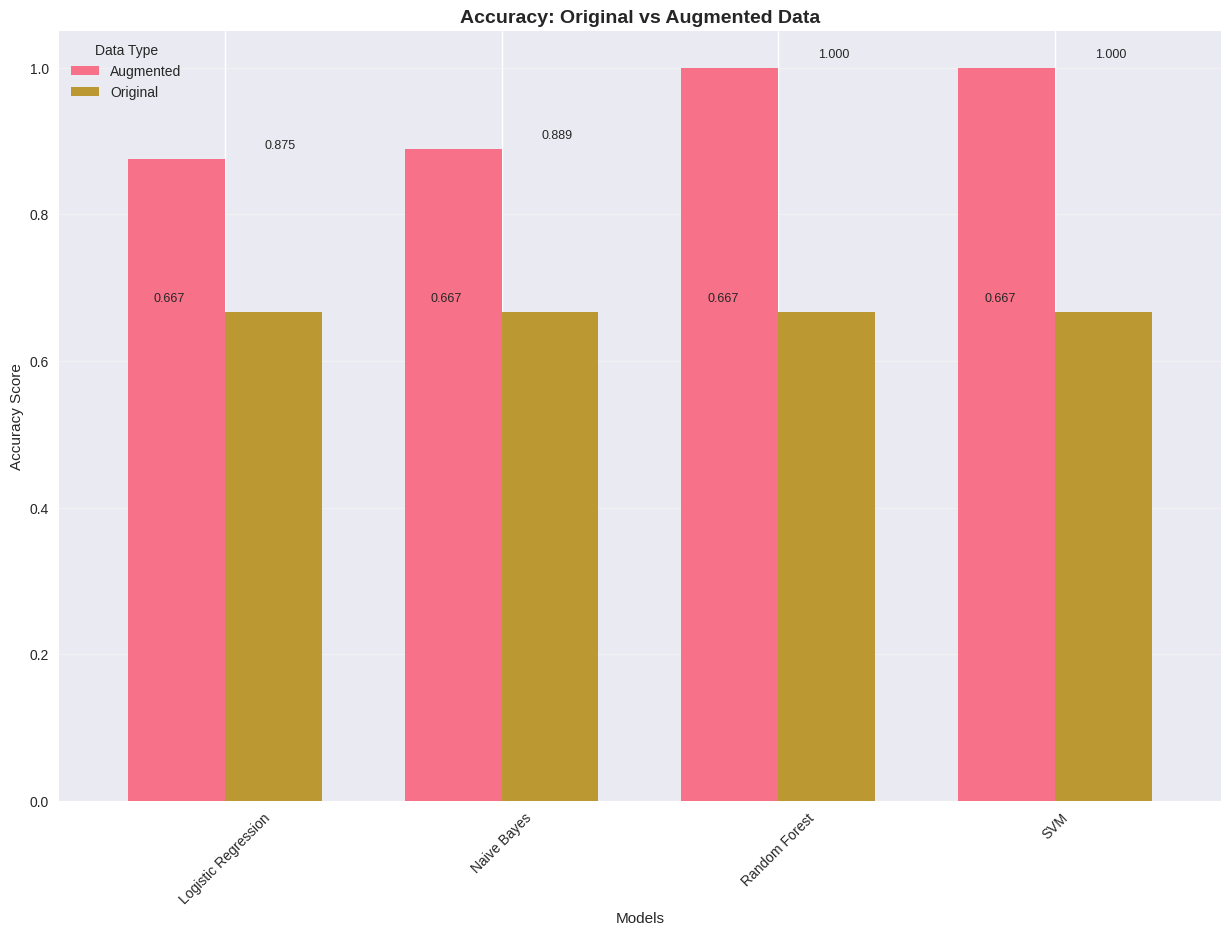

In [ ]:
comparison_df = compare_models_with_and_without_augmentation()

plt.figure(figsize=(15, 10))

accuracy_pivot = comparison_df.pivot(index='model', columns='condition', values='accuracy')
accuracy_pivot.plot(kind='bar', ax=plt.gca(), width=0.7)
plt.title('Accuracy: Original vs Augmented Data', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy Score')
plt.xlabel('Models')
plt.xticks(rotation=45)
plt.legend(title='Data Type')
plt.grid(axis='y', alpha=0.3)

# Adicionar valores no topo das barras
for i, model in enumerate(accuracy_pivot.index):
    plt.text(i-0.2, accuracy_pivot.loc[model, 'Original'] + 0.01, 
             f'{accuracy_pivot.loc[model, "Original"]:.3f}', 
             ha='center', va='bottom', fontsize=9)
    plt.text(i+0.2, accuracy_pivot.loc[model, 'Augmented'] + 0.01, 
             f'{accuracy_pivot.loc[model, "Augmented"]:.3f}', 
             ha='center', va='bottom', fontsize=9)

In [ ]:
comparison_df.head()

,model,condition,accuracy,precision,recall,f1
0,Naive Bayes,Original,0.25,0.111111,0.333333,0.166667
1,Naive Bayes,Augmented,1.00,1.000000,1.000000,1.000000
2,Logistic Regression,Original,0.50,0.333333,0.500000,0.388889
3,Logistic Regression,Augmented,1.00,1.000000,1.000000,1.000000
4,SVM,Original,0.50,0.333333,0.500000,0.388889


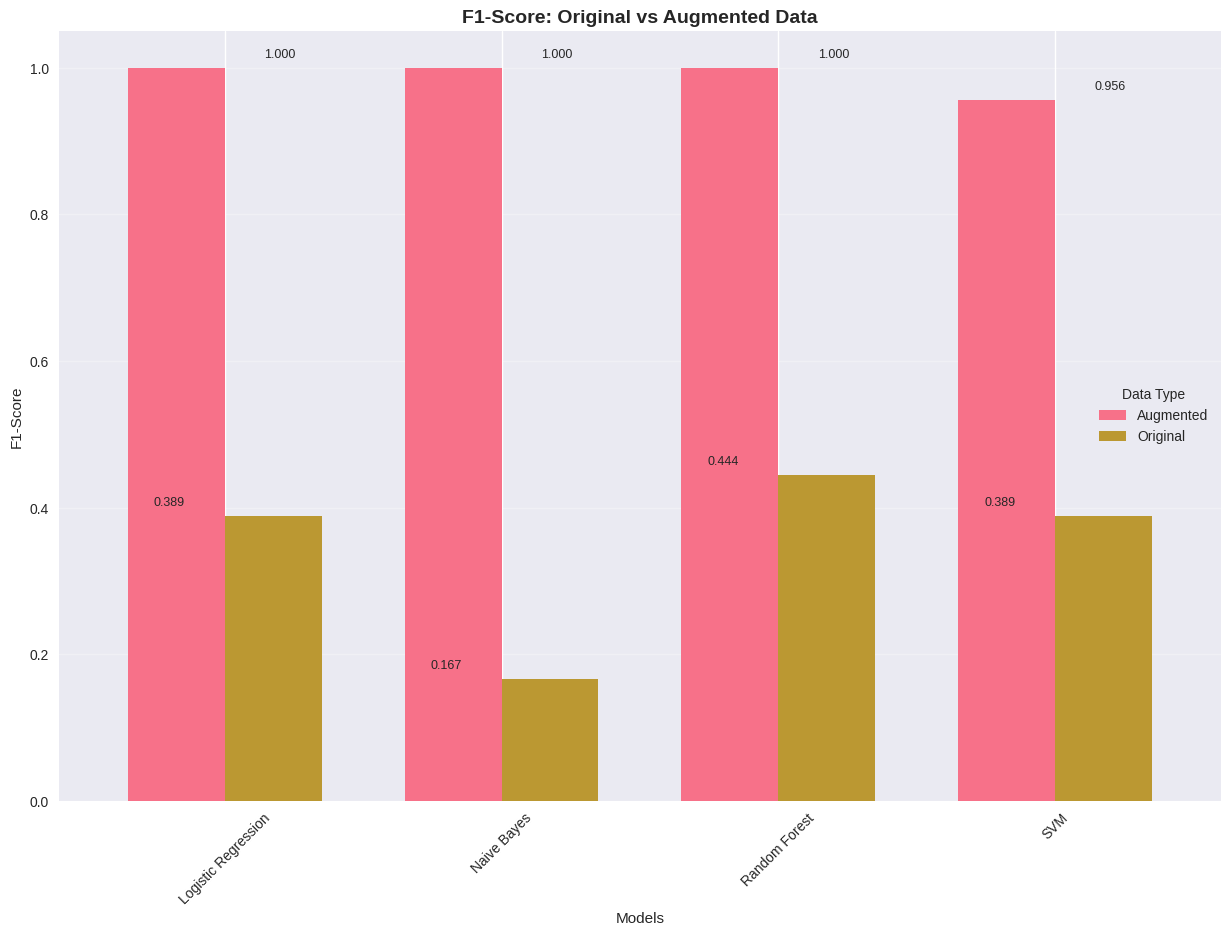

In [ ]:
plt.figure(figsize=(15, 10))
f1_pivot = comparison_df.pivot(index='model', columns='condition', values='f1')
f1_pivot.plot(kind='bar', ax=plt.gca(), width=0.7)
plt.title('F1-Score: Original vs Augmented Data', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score')
plt.xlabel('Models')
plt.xticks(rotation=45)
plt.legend(title='Data Type')
plt.grid(axis='y', alpha=0.3)

# Adicionar valores no topo das barras
for i, model in enumerate(f1_pivot.index):
    plt.text(i-0.2, f1_pivot.loc[model, 'Original'] + 0.01, 
             f'{f1_pivot.loc[model, "Original"]:.3f}', 
             ha='center', va='bottom', fontsize=9)
    plt.text(i+0.2, f1_pivot.loc[model, 'Augmented'] + 0.01, 
             f'{f1_pivot.loc[model, "Augmented"]:.3f}', 
             ha='center', va='bottom', fontsize=9)

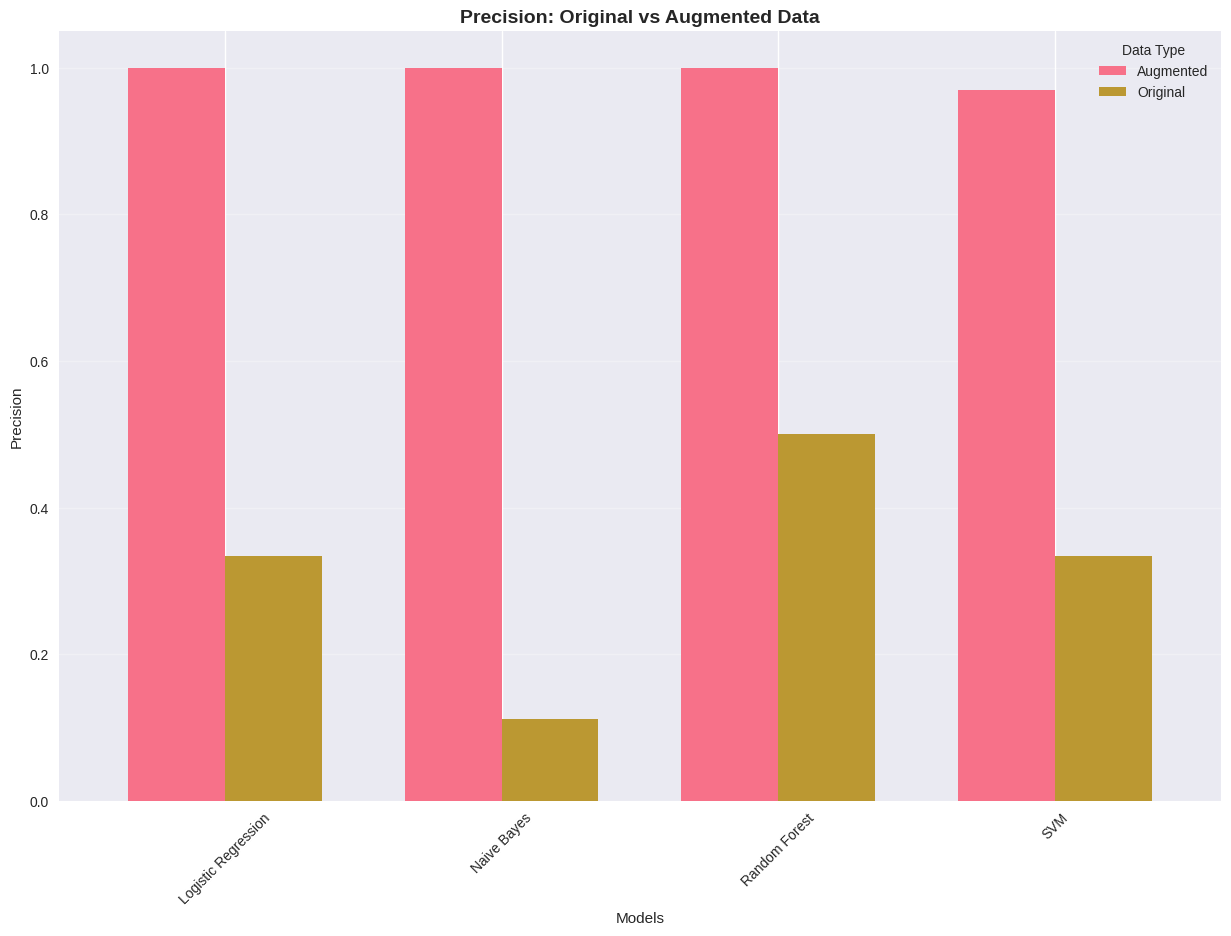

In [ ]:
plt.figure(figsize=(15, 10))
precision_pivot = comparison_df.pivot(index='model', columns='condition', values='precision')
precision_pivot.plot(kind='bar', ax=plt.gca(), width=0.7)
plt.title('Precision: Original vs Augmented Data', fontsize=14, fontweight='bold')
plt.ylabel('Precision')
plt.xlabel('Models')
plt.xticks(rotation=45)
plt.legend(title='Data Type')
plt.grid(axis='y', alpha=0.3)

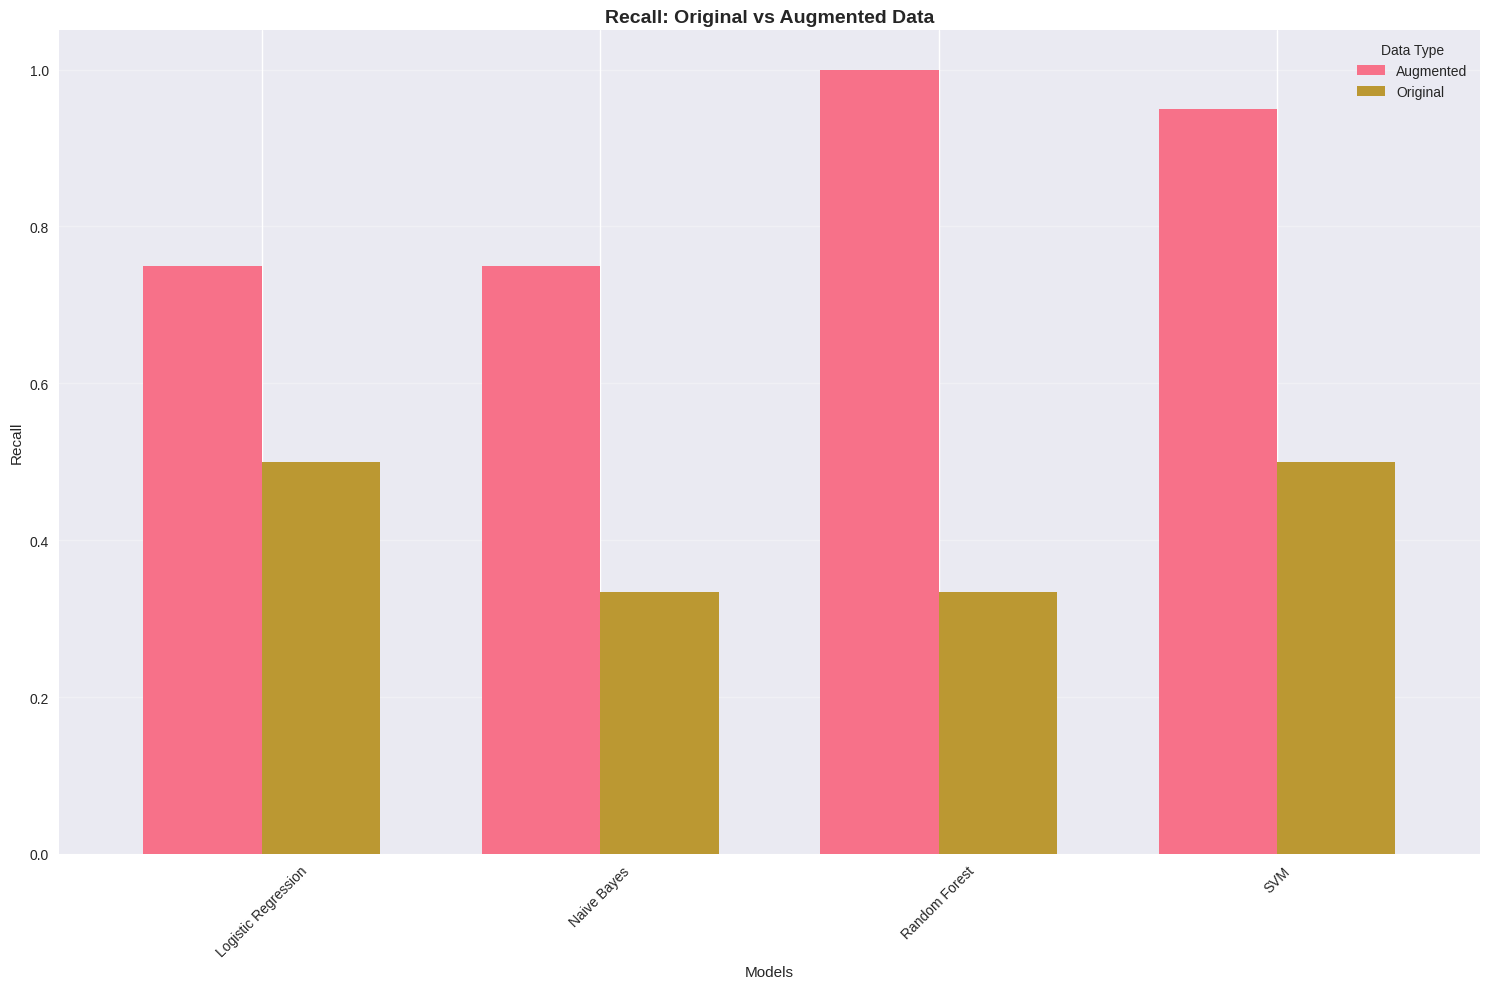

In [ ]:
plt.figure(figsize=(15, 10))
recall_pivot = comparison_df.pivot(index='model', columns='condition', values='recall')
recall_pivot.plot(kind='bar', ax=plt.gca(), width=0.7)
plt.title('Recall: Original vs Augmented Data', fontsize=14, fontweight='bold')
plt.ylabel('Recall')
plt.xlabel('Models')
plt.xticks(rotation=45)
plt.legend(title='Data Type')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

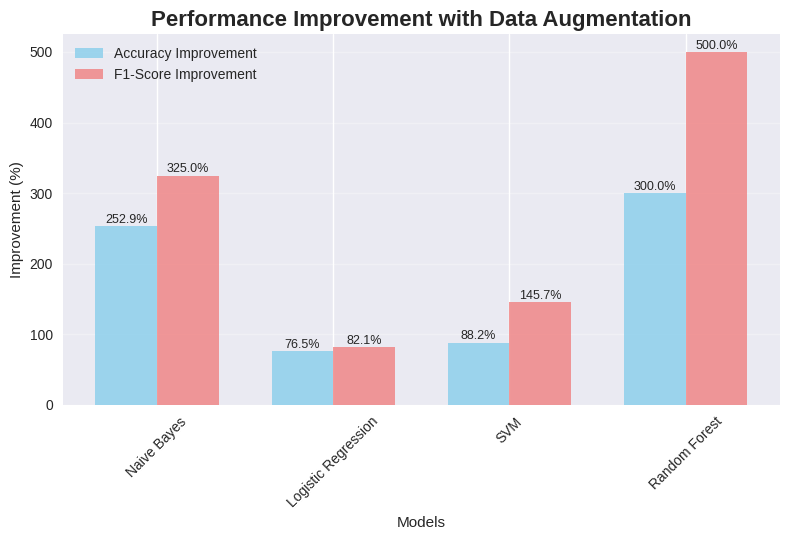

In [ ]:
improvement_data = []
for model in comparison_df['model'].unique():
    orig_acc = comparison_df[(comparison_df['model'] == model) & (comparison_df['condition'] == 'Original')]['accuracy'].iloc[0]
    aug_acc = comparison_df[(comparison_df['model'] == model) & (comparison_df['condition'] == 'Augmented')]['accuracy'].iloc[0]
    
    orig_f1 = comparison_df[(comparison_df['model'] == model) & (comparison_df['condition'] == 'Original')]['f1'].iloc[0]
    aug_f1 = comparison_df[(comparison_df['model'] == model) & (comparison_df['condition'] == 'Augmented')]['f1'].iloc[0]
    
    acc_improvement = ((aug_acc - orig_acc) / orig_acc * 100) if orig_acc > 0 else 0
    f1_improvement = ((aug_f1 - orig_f1) / orig_f1 * 100) if orig_f1 > 0 else 0
    
    improvement_data.append({
        'model': model,
        'accuracy_improvement': acc_improvement,
        'f1_improvement': f1_improvement
    })

improvement_df = pd.DataFrame(improvement_data)

# Plot de melhoria
x = np.arange(len(improvement_df))
width = 0.35

plt.bar(x - width/2, improvement_df['accuracy_improvement'], width, 
        label='Accuracy Improvement', alpha=0.8, color='skyblue')
plt.bar(x + width/2, improvement_df['f1_improvement'], width, 
        label='F1-Score Improvement', alpha=0.8, color='lightcoral')

plt.xlabel('Models')
plt.ylabel('Improvement (%)')
plt.title('Performance Improvement with Data Augmentation', fontsize=16, fontweight='bold')
plt.xticks(x, improvement_df['model'], rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Adicionar valores nas barras
for i, (acc_imp, f1_imp) in enumerate(zip(improvement_df['accuracy_improvement'], improvement_df['f1_improvement'])):
    plt.text(i - width/2, acc_imp + 0.5, f'{acc_imp:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, f1_imp + 0.5, f'{f1_imp:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

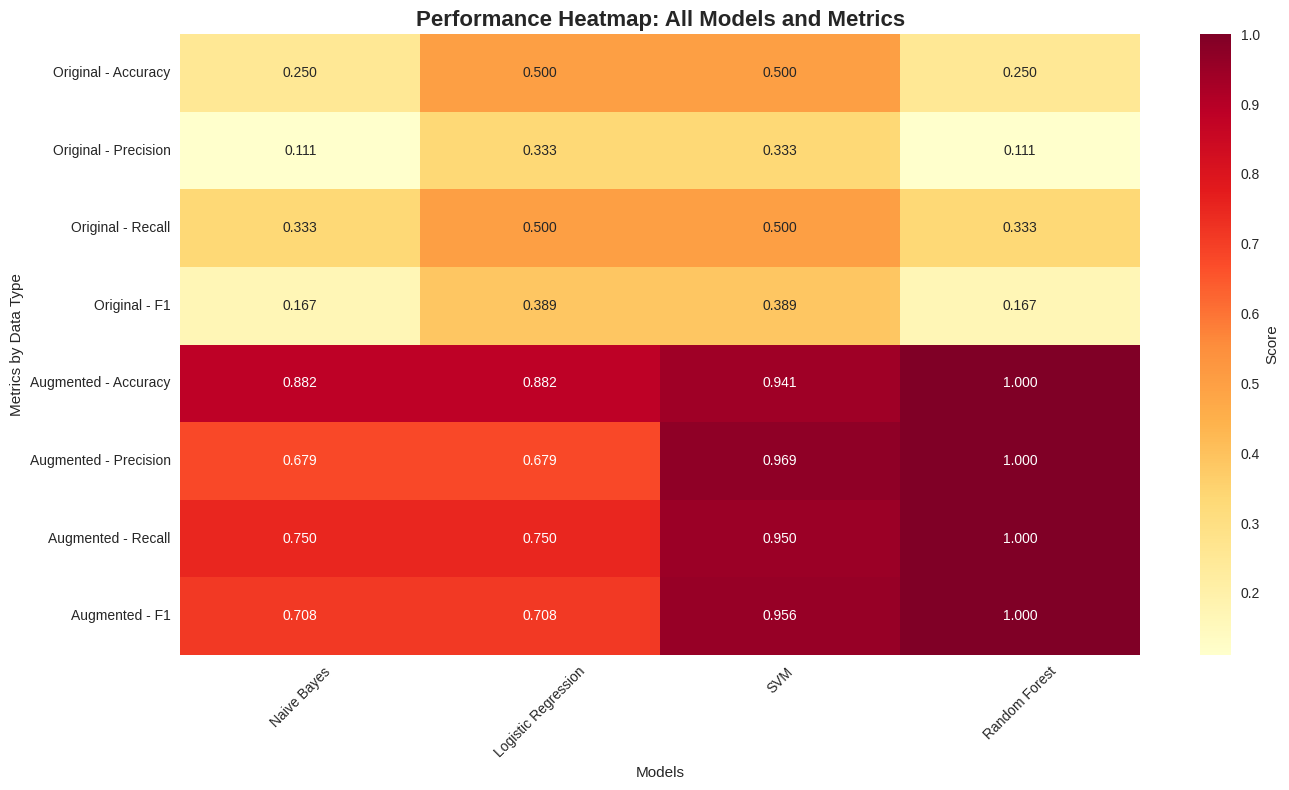

In [ ]:
plt.figure(figsize=(14, 8))

# Criar matriz para heatmap
metrics_matrix = []
models_list = comparison_df['model'].unique()
conditions = ['Original', 'Augmented']
metrics = ['accuracy', 'precision', 'recall', 'f1']

for condition in conditions:
    for metric in metrics:
        row = []
        for model in models_list:
            value = comparison_df[(comparison_df['model'] == model) & 
                                (comparison_df['condition'] == condition)][metric].iloc[0]
            row.append(value)
        metrics_matrix.append(row)

# Criar labels para o heatmap
y_labels = [f'{condition} - {metric.capitalize()}' for condition in conditions for metric in metrics]

# Plot heatmap
sns.heatmap(metrics_matrix, 
            xticklabels=models_list,
            yticklabels=y_labels,
            annot=True, 
            fmt='.3f', 
            cmap='YlOrRd',
            cbar_kws={'label': 'Score'})

plt.title('Performance Heatmap: All Models and Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Models')
plt.ylabel('Metrics by Data Type')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print("\n=== TABELA RESUMO DE PERFORMANCE ===")

summary_table = comparison_df.round(4)
print(summary_table.to_string(index=False))

print(f"Dataset Original: {len(df_original)} amostras")
print(f"Dataset Aumentado: {len(df_augmented)} amostras")
print(f"Aumento: {((len(df_augmented) - len(df_original)) / len(df_original) * 100):.1f}%")

# Calcular média de melhoria
avg_acc_improvement = improvement_df['accuracy_improvement'].mean()
avg_f1_improvement = improvement_df['f1_improvement'].mean()

print(f"  Accuracy: {avg_acc_improvement:+.1f}%")
print(f"  F1-Score: {avg_f1_improvement:+.1f}%")

# Melhor modelo
best_model_orig = comparison_df[comparison_df['condition'] == 'Original'].loc[
    comparison_df[comparison_df['condition'] == 'Original']['accuracy'].idxmax()
]['model']

best_model_aug = comparison_df[comparison_df['condition'] == 'Augmented'].loc[
    comparison_df[comparison_df['condition'] == 'Augmented']['accuracy'].idxmax()
]['model']

print(f"\nMelhor Modelo (Original): {best_model_orig}")
print(f"Melhor Modelo (Augmented): {best_model_aug}")



=== TABELA RESUMO DE PERFORMANCE ===
              model condition  accuracy  precision  recall     f1
        Naive Bayes  Original    0.2500     0.1111  0.3333 0.1667
        Naive Bayes Augmented    0.8824     0.6786  0.7500 0.7083
Logistic Regression  Original    0.5000     0.3333  0.5000 0.3889
Logistic Regression Augmented    0.8824     0.6786  0.7500 0.7083
                SVM  Original    0.5000     0.3333  0.5000 0.3889
                SVM Augmented    0.9412     0.9688  0.9500 0.9556
      Random Forest  Original    0.2500     0.1111  0.3333 0.1667
      Random Forest Augmented    1.0000     1.0000  1.0000 1.0000
Dataset Original: 17 amostras
Dataset Aumentado: 85 amostras
Aumento: 400.0%
  Accuracy: +179.4%
  F1-Score: +263.2%

Melhor Modelo (Original): Logistic Regression
Melhor Modelo (Augmented): Random Forest


## Testing text generation by Neural Networks

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from transformers import AutoTokenizer, AutoModel
import random
import os
import nltk
from collections import Counter
nltk.download('punkt')

[nltk_data] Downloading package punkt to /home/germano/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
df = pd.read_csv("../CSV/PIBIC - Transcrições - ansiedade_audio_transcriptions.csv")
    
dictionary = dict({
    "experiência pessoal": 1,
    "experiencia pessoal": 1,  # Handling potential variations
    "útil": 2,
    "util": 2,  # Handling potential variations
    "enganoso": 3,
    "outra": 4,
    "outro": 4,  # Handling potential variations
    "inglês": 5,
    "espanhol": 5,
    "não incluso": 5,
    "nao incluso": 5,  # Handling potential variations
    "repetido": 5,
    "indisponível": 5,
    "indisponivel": 5,  # Handling potential variations
    "excluído": 5,
    "excluido": 5,  # Handling potential variations
})

df['Classificação'] = df['Classificação'].str.rstrip()

df['Classificação'] = df['Classificação'].str.rstrip().str.lower()

df['Classificação'] = df['Classificação'].replace(dictionary)
df = df[~df['Classificação'].apply(lambda x: isinstance(x, str))]

df = df[df['Classificação'] != 5]

In [ ]:
df["Classificação"].unique()

array([3., 1., 2.])

In [ ]:
# Preencher valores nulos na coluna "Classificação" com 5 de forma vetorizada
df["Classificação"] = df["Classificação"].fillna(5)

df = df[df['Classificação'] != 5]

In [ ]:
df.head()

,ID,Transcription,Tag,Link,Plataform,Views,Classificação
8,32.0,Você sabia que o seu sentimentos duram no máxi...,ansiedade,https://www.instagram.com/reel/C-ldne6S5wG/?ig...,Instagram,1420394,3.0
13,53.0,Por que tem tanta gente tem gente demais na te...,ansiedade,https://www.instagram.com/reel/C-AnnGjugzS/?ig...,Instagram,3417117,1.0
46,NaN,Uma Mente eu venho sentindo um vazio tão grand...,ansiedade,TikTok,https://vm.tiktok.com/ZMSY4CRo3/,184.000,1.0
47,NaN,toda pessoa ansiosa tem esses três sintomas qu...,ansiedade,TikTok,https://vm.tiktok.com/ZMSY4bHQd/,190.000,3.0
48,NaN,ai mais um dia normal na minha vida vai vai es...,ansiedade,TikTok,https://vm.tiktok.com/ZMSY4pEq8/,983.000,1.0


In [ ]:
texts_by_class = {}
for class_id in df['Classificação'].unique():
    class_texts = df[df['Classificação'] == class_id]['Transcription'].tolist()
    texts_by_class[class_id] = class_texts
    print(f"Classe {class_id}: {len(class_texts)} textos")

Classe 3.0: 4 textos
Classe 1.0: 9 textos
Classe 2.0: 14 textos


In [ ]:
# Verificar se há classes com poucos textos
for class_id, texts in texts_by_class.items():
    if len(texts) < 2:
        print(f"Atenção: Classe {class_id} tem apenas {len(texts)} textos. Pode ser insuficiente para treinamento.")
    
    # criar textos para as classes com poucos textos
    if len(texts) < 2:
        original_text = df[df['Classificação'] == class_id]['Transcription'].iloc[0]

        new_texts = []

        new_texts.append(synonym_replacement(original_text))
        new_texts.append(random_insertion(original_text))
        new_texts.append(random_swap(original_text))
        new_texts.append(random_deletion(original_text))
        
        texts_by_class[class_id].extend(new_texts)
        print(f"Classe {class_id} aumentada para {len(texts_by_class[class_id])} textos.")

In [ ]:
texts_by_class

{3.0: ['Você sabia que o seu sentimentos duram no máximo 90 segundos amor ansiedade medo e raiva Durão um minuto e meio eles só vão durar mais do que isso se você alimentar eles com pensamentos de alguma forma você escolhe se você continua sentindo medo se você continua amando tal pessoa se você continua sentindo raiva de tal situação aí tem um negócio que chama estrutura de processamento cerebral que basicamente significa se você sempre alimentou aquela emoção o seu cérebro vai fazer isso automaticamente o que acontece com muitas pessoas que sentem ansiedade e uma das coisas que você pode fazer para mudar isso de acordo com a autora feito Harper é você pensar em outra coisa a partir do momento em que o sentimento vida então no momento que o sentimento vivo você se distrai você pensa quantas medalhas de ouro o Brasil ganhou até agora que dia que é o aniversário de tal amiga minha esse livro que ele vale muito a pena ele fala sobre traumas ele fala sobre ansiedade ele fala sobre como vo

In [ ]:
model_name = "neuralmind/bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
embedding_model = AutoModel.from_pretrained(model_name)

def get_text_embeddings(texts, max_length=128):
    """Converte textos em embeddings usando BERT"""
    embeddings = []
    
    for text in texts:
        # Tokenizar
        inputs = tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )
        
        # Obter embeddings
        with torch.no_grad():
            outputs = embedding_model(**inputs)
            # Usar o [CLS] token como representação do texto
            embedding = outputs.last_hidden_state[:, 0, :].squeeze()
            embeddings.append(embedding.numpy())
    
    return np.array(embeddings)

print("Gerando embeddings...")
embeddings_by_class = {}
for class_id, texts in texts_by_class.items():
    print(f"Processando classe {class_id}...")
    embeddings = get_text_embeddings(texts[:100])
    embeddings_by_class[class_id] = embeddings
    print(f"  Shape: {embeddings.shape}")

/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Gerando embeddings...
Processando classe 3.0...
  Shape: (4, 768)
Processando classe 1.0...
  Shape: (9, 768)
Processando classe 2.0...
  Shape: (14, 768)


In [ ]:
class Generator(nn.Module):
    """Gerador da GAN para criar embeddings sintéticos"""
    def __init__(self, noise_dim=100, embedding_dim=768, hidden_dim=512):
        super(Generator, self).__init__()
        
        self.model = nn.Sequential(
            # Camada 1
            nn.Linear(noise_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Camada 2
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Camada 3
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Camada de saída
            nn.Linear(hidden_dim, embedding_dim),
            nn.Tanh()  # Normalizar saída
        )
    
    def forward(self, noise):
        return self.model(noise)

class Discriminator(nn.Module):
    """Discriminador da GAN para distinguir embeddings reais de sintéticos"""
    def __init__(self, embedding_dim=768, hidden_dim=512):
        super(Discriminator, self).__init__()
        
        self.model = nn.Sequential(
            # Camada 1
            nn.Linear(embedding_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            # Camada 2
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            # Camada 3
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            # Camada de saída
            nn.Linear(hidden_dim // 4, 1),
            nn.Sigmoid()
        )
    
    def forward(self, embedding):
        return self.model(embedding)

In [ ]:
def train_gan_for_class(embeddings, epochs=100, batch_size=16, noise_dim=100):
    """Treina uma GAN para uma classe específica"""
    
    # Verificar se temos dados suficientes
    if len(embeddings) < batch_size:
        print(f"Poucos dados ({len(embeddings)}), ajustando batch_size para {len(embeddings)}")
        batch_size = len(embeddings)
    
    # Inicializar modelos
    embedding_dim = embeddings.shape[1]
    generator = Generator(noise_dim, embedding_dim)
    discriminator = Discriminator(embedding_dim)
    
    # Otimizadores
    g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    
    # Função de perda
    criterion = nn.BCELoss()
    
    # Converter para tensor
    real_embeddings = torch.FloatTensor(embeddings)
    
    # Listas para armazenar perdas
    g_losses = []
    d_losses = []
    
    print(f"Iniciando treinamento com {len(embeddings)} amostras...")
    
    for epoch in range(epochs):
        # Embaralhar dados
        indices = torch.randperm(len(real_embeddings))
        
        epoch_g_loss = 0
        epoch_d_loss = 0
        num_batches = 0
        
        for i in range(0, len(indices), batch_size):
            batch_indices = indices[i:i+batch_size]
            real_batch = real_embeddings[batch_indices]
            batch_len = len(real_batch)
            
            # Labels
            real_labels = torch.ones(batch_len, 1)
            fake_labels = torch.zeros(batch_len, 1)
            
            # ===== TREINAR DISCRIMINADOR =====
            d_optimizer.zero_grad()
            
            # Discriminador com dados reais
            d_real = discriminator(real_batch)
            d_real_loss = criterion(d_real, real_labels)
            
            # Discriminador com dados sintéticos
            noise = torch.randn(batch_len, noise_dim)
            fake_batch = generator(noise)
            d_fake = discriminator(fake_batch.detach())
            d_fake_loss = criterion(d_fake, fake_labels)
            
            # Total discriminador
            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            d_optimizer.step()
            
            # ===== TREINAR GERADOR =====
            g_optimizer.zero_grad()
            
            # Gerador tenta enganar discriminador
            noise = torch.randn(batch_len, noise_dim)
            fake_batch = generator(noise)
            d_fake = discriminator(fake_batch)
            g_loss = criterion(d_fake, real_labels)
            
            g_loss.backward()
            g_optimizer.step()
            
            # Acumular perdas
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
            num_batches += 1
        
        # Média das perdas da época
        avg_g_loss = epoch_g_loss / num_batches
        avg_d_loss = epoch_d_loss / num_batches
        
        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch}: G_Loss = {avg_g_loss:.4f}, D_Loss = {avg_d_loss:.4f}")
    
    return generator, discriminator, g_losses, d_losses

In [ ]:
generators = {}
discriminators = {}
training_histories = {}

for class_id, embeddings in embeddings_by_class.items():
    print(f"\n--- TREINANDO GAN PARA CLASSE {class_id} ---")
    
    try:
        generator, discriminator, g_losses, d_losses = train_gan_for_class(
            embeddings, epochs=50, batch_size=5
        )
        
        generators[class_id] = generator
        discriminators[class_id] = discriminator
        training_histories[class_id] = {'g_losses': g_losses, 'd_losses': d_losses}
        
        print(f"✓ GAN treinada para classe {class_id}")
        
    except Exception as e:
        print(f"Erro ao treinar GAN para classe {class_id}: {e}")


--- TREINANDO GAN PARA CLASSE 3.0 ---
Poucos dados (4), ajustando batch_size para 4
Iniciando treinamento com 4 amostras...
Epoch 0: G_Loss = 0.6853, D_Loss = 1.3894
Epoch 20: G_Loss = 0.6145, D_Loss = 1.2905
Epoch 40: G_Loss = 0.9409, D_Loss = 1.0082
✓ GAN treinada para classe 3.0

--- TREINANDO GAN PARA CLASSE 1.0 ---
Iniciando treinamento com 9 amostras...
Epoch 0: G_Loss = 0.7208, D_Loss = 1.3980
Epoch 20: G_Loss = 0.9711, D_Loss = 0.9977
Epoch 40: G_Loss = 2.0325, D_Loss = 0.3596
✓ GAN treinada para classe 1.0

--- TREINANDO GAN PARA CLASSE 2.0 ---
Iniciando treinamento com 14 amostras...
Epoch 0: G_Loss = 0.7108, D_Loss = 1.3698
Epoch 20: G_Loss = 1.5898, D_Loss = 0.5997
Epoch 40: G_Loss = 4.1165, D_Loss = 0.0889
✓ GAN treinada para classe 2.0


In [ ]:
def generate_synthetic_embeddings(generator, num_samples=50, noise_dim=100):
    """Gera embeddings sintéticos usando o gerador treinado"""
    generator.eval()
    
    with torch.no_grad():
        noise = torch.randn(num_samples, noise_dim)
        synthetic_embeddings = generator(noise)
    
    return synthetic_embeddings.numpy()

In [ ]:
synthetic_embeddings_by_class = {}

for class_id, generator in generators.items():
    print(f"Gerando embeddings sintéticos para classe {class_id}...")
    
    # Gerar mais amostras para classes com poucos dados
    original_count = len(embeddings_by_class[class_id])
    target_count = max(100, original_count * 3)  # Pelo menos 100 ou 3x o original
    
    synthetic_embeddings = generate_synthetic_embeddings(
        generator, num_samples=target_count
    )
    
    synthetic_embeddings_by_class[class_id] = synthetic_embeddings
    
    print(f"  Originais: {original_count}, Sintéticos: {len(synthetic_embeddings)}")

Gerando embeddings sintéticos para classe 3.0...
  Originais: 4, Sintéticos: 100
Gerando embeddings sintéticos para classe 1.0...
  Originais: 9, Sintéticos: 100
Gerando embeddings sintéticos para classe 2.0...
  Originais: 14, Sintéticos: 100


In [ ]:
def embedding_to_text_simple(embedding, original_texts, similarity_threshold=0.7):
    """
    Converte embedding sintético em texto usando similaridade com textos originais.
    Esta é uma abordagem simplificada - para produção, usaria modelos mais sofisticados.
    """
    # Calcular similaridade com embeddings originais
    original_embeddings = get_text_embeddings(original_texts[:20])  # Limitar para performance
    
    # Calcular similaridade coseno
    similarities = []
    for orig_emb in original_embeddings:
        similarity = np.dot(embedding, orig_emb) / (np.linalg.norm(embedding) * np.linalg.norm(orig_emb))
        similarities.append(similarity)
    
    # Encontrar texto mais similar
    most_similar_idx = np.argmax(similarities)
    most_similar_text = original_texts[most_similar_idx]
    max_similarity = similarities[most_similar_idx]
    
    # Se similaridade é muito baixa, criar variação do texto mais similar
    if max_similarity < similarity_threshold:
        # Aplicar técnicas simples de variação
        words = most_similar_text.split()
        
        # Técnicas de variação
        if len(words) > 3:
            # Trocar ordem de algumas palavras
            if random.random() > 0.5:
                idx1, idx2 = random.sample(range(len(words)), 2)
                words[idx1], words[idx2] = words[idx2], words[idx1]
            
            # Adicionar conectivos
            if random.random() > 0.5:
                connectors = ["então", "mas", "porém", "além disso", "na verdade"]
                connector = random.choice(connectors)
                words.insert(random.randint(0, len(words)), connector)
        
        return ' '.join(words)
    
    return most_similar_text

In [ ]:
synthetic_texts_by_class = {}
for class_id, synthetic_embeddings in synthetic_embeddings_by_class.items():
    print(f"Processando classe {class_id}...")
    
    original_texts = texts_by_class[class_id]
    synthetic_texts = []
    
    # Processar em lotes menores para evitar sobrecarga
    batch_size = 10
    for i in range(0, len(synthetic_embeddings), batch_size):
        batch_embeddings = synthetic_embeddings[i:i+batch_size]
        
        for embedding in batch_embeddings:
            try:
                synthetic_text = embedding_to_text_simple(embedding, original_texts)
                synthetic_texts.append(synthetic_text)
            except Exception as e:
                print(f"Erro ao converter embedding: {e}")
                # Usar texto original como fallback
                synthetic_texts.append(random.choice(original_texts))
        
        if i % 50 == 0:
            print(f"  Processados {min(i+batch_size, len(synthetic_embeddings))}/{len(synthetic_embeddings)}")
    
    synthetic_texts_by_class[class_id] = synthetic_texts
    print(f"  Gerados {len(synthetic_texts)} textos sintéticos")


Processando classe 3.0...
  Processados 10/100
  Processados 60/100
  Gerados 100 textos sintéticos
Processando classe 1.0...
  Processados 10/100
  Processados 60/100
  Gerados 100 textos sintéticos
Processando classe 2.0...
  Processados 10/100
  Processados 60/100
  Gerados 100 textos sintéticos


In [ ]:
gan_augmented_data = []

# Adicionar dados originais
for _, row in df.iterrows():
    gan_augmented_data.append({
        'Transcription': row['Transcription'],
        'Classificação': row['Classificação'],
        'augmentation_type': 'original'
    })

# Adicionar dados sintéticos das GANs
for class_id, synthetic_texts in synthetic_texts_by_class.items():
    for text in synthetic_texts:
        gan_augmented_data.append({
            'Transcription': text,
            'Classificação': class_id,
            'augmentation_type': 'gan_synthetic'
        })

# Criar DataFrame
df_gan_augmented = pd.DataFrame(gan_augmented_data)

print(f"Dataset original: {len(df)} amostras")
print(f"Dataset aumentado com GANs: {len(df_gan_augmented)} amostras")
print(f"Aumento: {((len(df_gan_augmented) - len(df)) / len(df) * 100):.1f}%")

print("\nDistribuição das classes no dataset GAN-aumentado:")
print(df_gan_augmented['Classificação'].value_counts())

Dataset original: 27 amostras
Dataset aumentado com GANs: 327 amostras
Aumento: 1111.1%

Distribuição das classes no dataset GAN-aumentado:
Classificação
2.0    114
1.0    109
3.0    104
Name: count, dtype: int64


In [ ]:
for class_id in df_gan_augmented['Classificação'].unique():
    print(f"\nClasse {class_id}:")
    
    # Original
    original_sample = df_gan_augmented[
        (df_gan_augmented['Classificação'] == class_id) & 
        (df_gan_augmented['augmentation_type'] == 'original')
    ]['Transcription'].iloc[0]
    print(f"Original: {original_sample[:100]}...")
    
    # GAN
    gan_samples = df_gan_augmented[
        (df_gan_augmented['Classificação'] == class_id) & 
        (df_gan_augmented['augmentation_type'] == 'gan_synthetic')
    ]
    
    if not gan_samples.empty:
        gan_sample = gan_samples['Transcription'].iloc[0]
        print(f"GAN: {gan_sample[:100]}...")


Classe 3.0:
Original: Você sabia que o seu sentimentos duram no máximo 90 segundos amor ansiedade medo e raiva Durão um mi...
GAN: toda pessoa ansiosa tem esses três sintomas que eu vou falar para você meu nome é Stênio Lima Eu sou...

Classe 1.0:
Original: Por que tem tanta gente tem gente demais na terra Precisamos de outra praga Por que tanta gente...
GAN: sim porque a ansiedade é um bagulho que eu tenho só que eu não falo na Live que eu tenho tá ligado e...

Classe 2.0:
Original: que que é TDH muito simples é sério o que pensa muito mais que a média uma velocidade muito maior ex...
GAN: vou falar para você 6 dores que a ansiedade pode te causar inclusive talvez assista seja mais import...


In [ ]:
vectorizer = TfidfVectorizer()
df_gan_augmented['tokenized_words_joined'] = df_gan_augmented['Transcription'].apply(lambda x: ' '.join(word_tokenize(str(x))))
X = vectorizer.fit_transform(df_gan_augmented['tokenized_words_joined'])
df_gan_augmented['Classificação'] = df_gan_augmented['Classificação'].astype('int')
y = df_gan_augmented['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

dummy_model = DummyClassifier(strategy="stratified", random_state=42)
dummy_model.fit(X_train, y_train)
y_pred_dummy = dummy_model.predict(X_val)

print("Dummy Model")
print("Accuracy: ", accuracy_score(y_val, y_pred_dummy))
print("Precision: ", precision_score(y_val, y_pred_dummy, average='macro'))
print("Recall: ", recall_score(y_val, y_pred_dummy, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred_dummy, average='macro'))


Dummy Model
Accuracy:  0.19696969696969696
Precision:  0.20813595007143393
Recall:  0.1898148148148148
F1-Score:  0.19025389025389025


### Plots

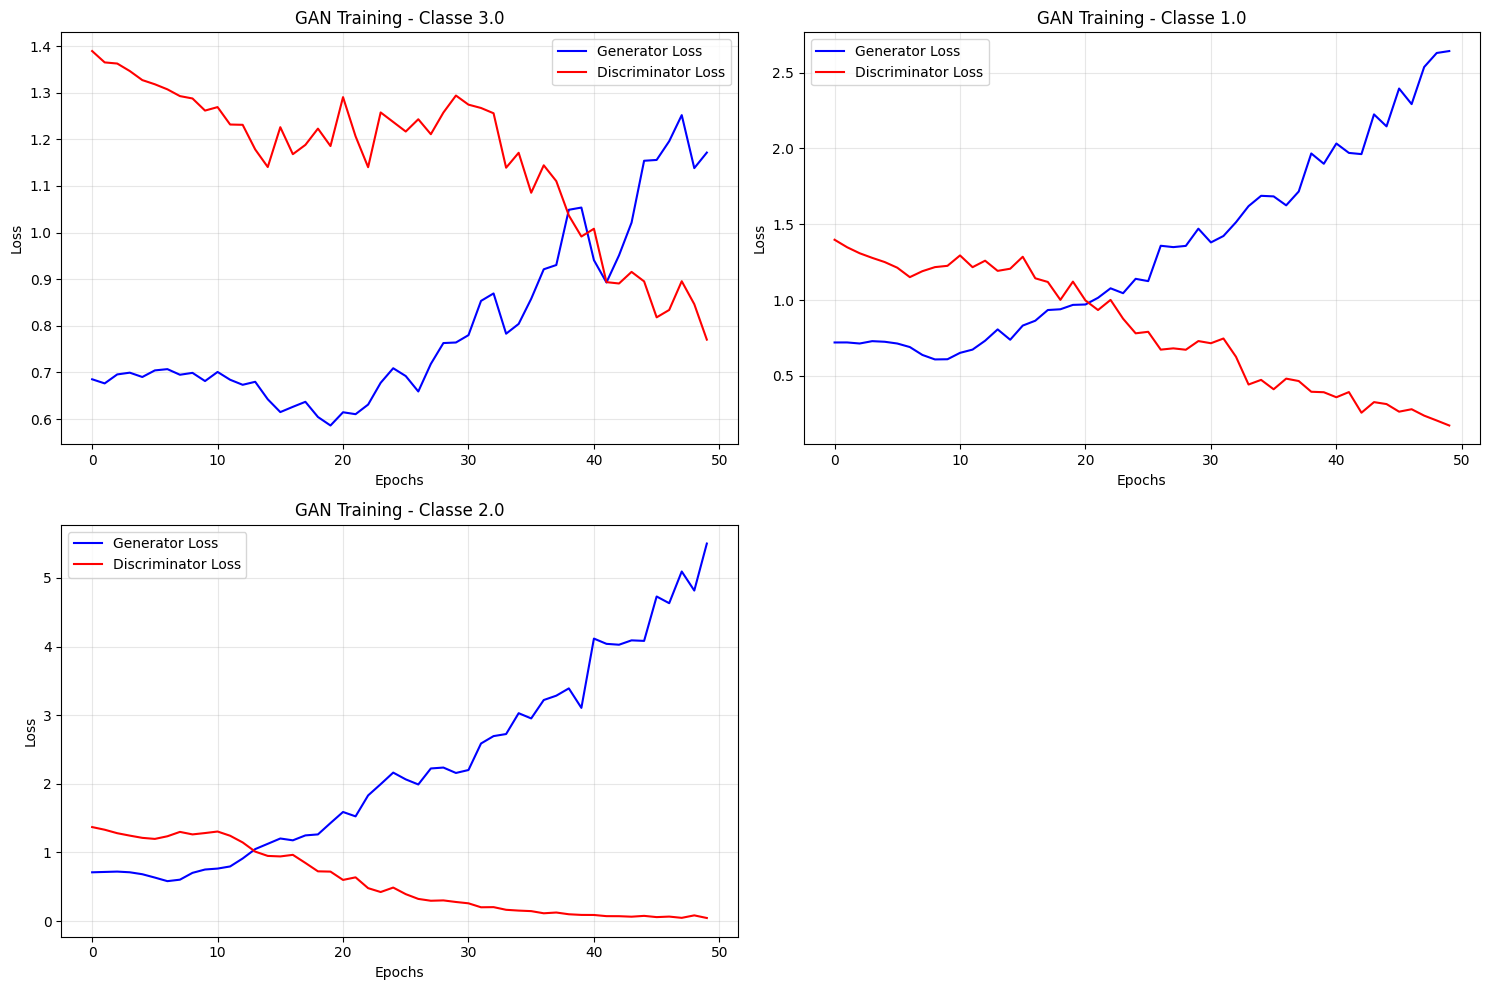

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

plot_idx = 0
for class_id, history in training_histories.items():
    if plot_idx >= 4:
        break
    
    ax = axes[plot_idx]
    
    epochs = range(len(history['g_losses']))
    ax.plot(epochs, history['g_losses'], label='Generator Loss', color='blue')
    ax.plot(epochs, history['d_losses'], label='Discriminator Loss', color='red')
    
    ax.set_title(f'GAN Training - Classe {class_id}')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plot_idx += 1

# Remover subplots não utilizados
for i in range(plot_idx, 4):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

# Processar dataset GAN-aumentado
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('portuguese'))

df_gan_augmented['tokenized_words'] = df_gan_augmented['Transcription'].apply(
    lambda x: word_tokenize(str(x))
)
df_gan_augmented['removed_stopwords'] = df_gan_augmented['tokenized_words'].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)
df_gan_augmented['tokenized_words_joined'] = df_gan_augmented['removed_stopwords'].apply(
    lambda x: ' '.join(x)
)

def test_model_performance_gan(data, title):
    """Testa performance do modelo com dados GAN-aumentados usando cross-validation"""
    print(f"\n=== {title} ===")
    print(f"Tamanho do dataset: {len(data)}")
    
    # Preparar dados
    X_text = data['tokenized_words_joined']
    y = data['Classificação'].astype('int')
    
    # Configurar cross-validation
    # Usar StratifiedKFold para manter proporção das classes
    cv_folds = min(5, len(data) // 10) if len(data) >= 20 else 3  # Ajustar número de folds
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    # Testar múltiplos modelos
    models = {
        'Naive Bayes': Pipeline([
            ('vectorizer', TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)),
            ('classifier', MultinomialNB(alpha=1.0))
        ]),
        'Logistic Regression': Pipeline([
            ('vectorizer', TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)),
            ('classifier', LogisticRegression(max_iter=1000, random_state=42))
        ]),
        'SVM': Pipeline([
            ('vectorizer', TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)),
            ('classifier', SVC(kernel='linear', random_state=42, C=1.0, class_weight='balanced'))
        ]),
        'Random Forest': Pipeline([
            ('vectorizer', TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)),
            ('classifier', RandomForestClassifier(n_estimators=50, class_weight='balanced', min_samples_split=2, random_state=42))
        ])
    }
    
    results = {}
    
    for model_name, pipeline in models.items():
        try:
            print(f"Avaliando {model_name} com {cv_folds}-fold CV...")
            
            # Cross-validation para múltiplas métricas
            cv_accuracy = cross_val_score(pipeline, X_text, y, cv=cv, scoring='accuracy')
            cv_f1 = cross_val_score(pipeline, X_text, y, cv=cv, scoring='f1_macro')
            cv_precision = cross_val_score(pipeline, X_text, y, cv=cv, scoring='precision_macro')
            cv_recall = cross_val_score(pipeline, X_text, y, cv=cv, scoring='recall_macro')
            
            results[model_name] = {
                'accuracy': cv_accuracy.mean(),
                'accuracy_std': cv_accuracy.std(),
                'f1': cv_f1.mean(),
                'f1_std': cv_f1.std(),
                'precision': cv_precision.mean(),
                'precision_std': cv_precision.std(),
                'recall': cv_recall.mean(),
                'recall_std': cv_recall.std()
            }
            
            print(f"{model_name}:")
            print(f"  Accuracy: {results[model_name]['accuracy']:.4f} (±{results[model_name]['accuracy_std']:.4f})")
            print(f"  F1-Score: {results[model_name]['f1']:.4f} (±{results[model_name]['f1_std']:.4f})")
            
        except Exception as e:
            print(f"Erro com {model_name}: {e}")
            results[model_name] = {
                'accuracy': 0, 'accuracy_std': 0,
                'f1': 0, 'f1_std': 0,
                'precision': 0, 'precision_std': 0,
                'recall': 0, 'recall_std': 0
            }
    
    return results

In [ ]:
df_original_processed = df.copy()
df_original_processed['tokenized_words'] = df_original_processed['Transcription'].apply(
    lambda x: word_tokenize(str(x))
)
df_original_processed['removed_stopwords'] = df_original_processed['tokenized_words'].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)
df_original_processed['tokenized_words_joined'] = df_original_processed['removed_stopwords'].apply(
    lambda x: ' '.join(x)
)

results_original_gan = test_model_performance_gan(df_original_processed, "DADOS ORIGINAIS")
results_gan_augmented = test_model_performance_gan(df_gan_augmented, "DADOS GAN-AUMENTADOS")


=== DADOS ORIGINAIS ===
Tamanho do dataset: 27
Avaliando Naive Bayes com 2-fold CV...
Naive Bayes:
  Accuracy: 0.5192 (±0.0192)
  F1-Score: 0.2278 (±0.0056)
Avaliando Logistic Regression com 2-fold CV...
Logistic Regression:
  Accuracy: 0.5192 (±0.0192)
  F1-Score: 0.2278 (±0.0056)
Avaliando SVM com 2-fold CV...


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

SVM:
  Accuracy: 0.5577 (±0.0577)
  F1-Score: 0.3240 (±0.1018)
Avaliando Random Forest com 2-fold CV...


/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/germano/Documents/MindVid_Research/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Random Forest:
  Accuracy: 0.5549 (±0.0165)
  F1-Score: 0.3897 (±0.0008)

=== DADOS GAN-AUMENTADOS ===
Tamanho do dataset: 327
Avaliando Naive Bayes com 5-fold CV...
Naive Bayes:
  Accuracy: 0.9817 (±0.0177)
  F1-Score: 0.9819 (±0.0175)
Avaliando Logistic Regression com 5-fold CV...
Logistic Regression:
  Accuracy: 0.9847 (±0.0194)
  F1-Score: 0.9849 (±0.0192)
Avaliando SVM com 5-fold CV...
SVM:
  Accuracy: 0.9909 (±0.0121)
  F1-Score: 0.9910 (±0.0119)
Avaliando Random Forest com 5-fold CV...
Random Forest:
  Accuracy: 0.9847 (±0.0194)
  F1-Score: 0.9850 (±0.0190)


In [ ]:
print("Verificando possível data leakage...")

original_texts = set(df_gan_augmented[df_gan_augmented['augmentation_type'] == 'original']['Transcription'])
synthetic_texts = set(df_gan_augmented[df_gan_augmented['augmentation_type'] == 'gan_synthetic']['Transcription'])

duplicates = original_texts.intersection(synthetic_texts)
print(f"Textos duplicados entre original e sintético: {len(duplicates)}")

if duplicates:
    print("Exemplos de duplicatas:")
    for i, dup in enumerate(list(duplicates)[:3]):
        print(f"  {i+1}: {dup[:100]}...")

Verificando possível data leakage...
Textos duplicados entre original e sintético: 14
Exemplos de duplicatas:
  1: sim porque a ansiedade é um bagulho que eu tenho só que eu não falo na Live que eu tenho tá ligado e...
  2: Por que tem tanta gente tem gente demais na terra Precisamos de outra praga Por que tanta gente...
  3: tudo errado tudo errado cara hahaha...


In [ ]:
comparison_data = []
for model_name in results_original_gan.keys():
    for metric in ['accuracy', 'f1', 'precision', 'recall']:
        original_val = results_original_gan[model_name][metric]
        gan_val = results_gan_augmented[model_name][metric]
        improvement = ((gan_val - original_val) / original_val * 100) if original_val > 0 else 0
        
        comparison_data.append({
            'Model': model_name,
            'Metric': metric,
            'Original': original_val,
            'GAN_Augmented': gan_val,
            'Improvement_%': improvement
        })

comparison_df_gan = pd.DataFrame(comparison_data)

NameError: name 'results_original_gan' is not defined

In [ ]:
print(comparison_df_gan.round(4).to_string(index=False))

              Model    Metric  Original  GAN_Augmented  Improvement_%
        Naive Bayes  accuracy    0.5192         0.9816        89.0460
        Naive Bayes        f1    0.2278         0.9816       330.9459
        Naive Bayes precision    0.1731         0.9832       468.0609
        Naive Bayes    recall    0.3333         0.9817       194.4984
Logistic Regression  accuracy    0.5192         0.9938        91.4074
Logistic Regression        f1    0.2278         0.9939       336.3415
Logistic Regression precision    0.1731         0.9947       474.6963
Logistic Regression    recall    0.3333         0.9937       198.0952
                SVM  accuracy    0.5577         0.9938        78.2069
                SVM        f1    0.3240         0.9939       206.7594
                SVM precision    0.2944         0.9947       237.8113
                SVM    recall    0.3929         0.9937       152.9293
      Random Forest  accuracy    0.5549         0.9877        77.9802
      Random Forest 

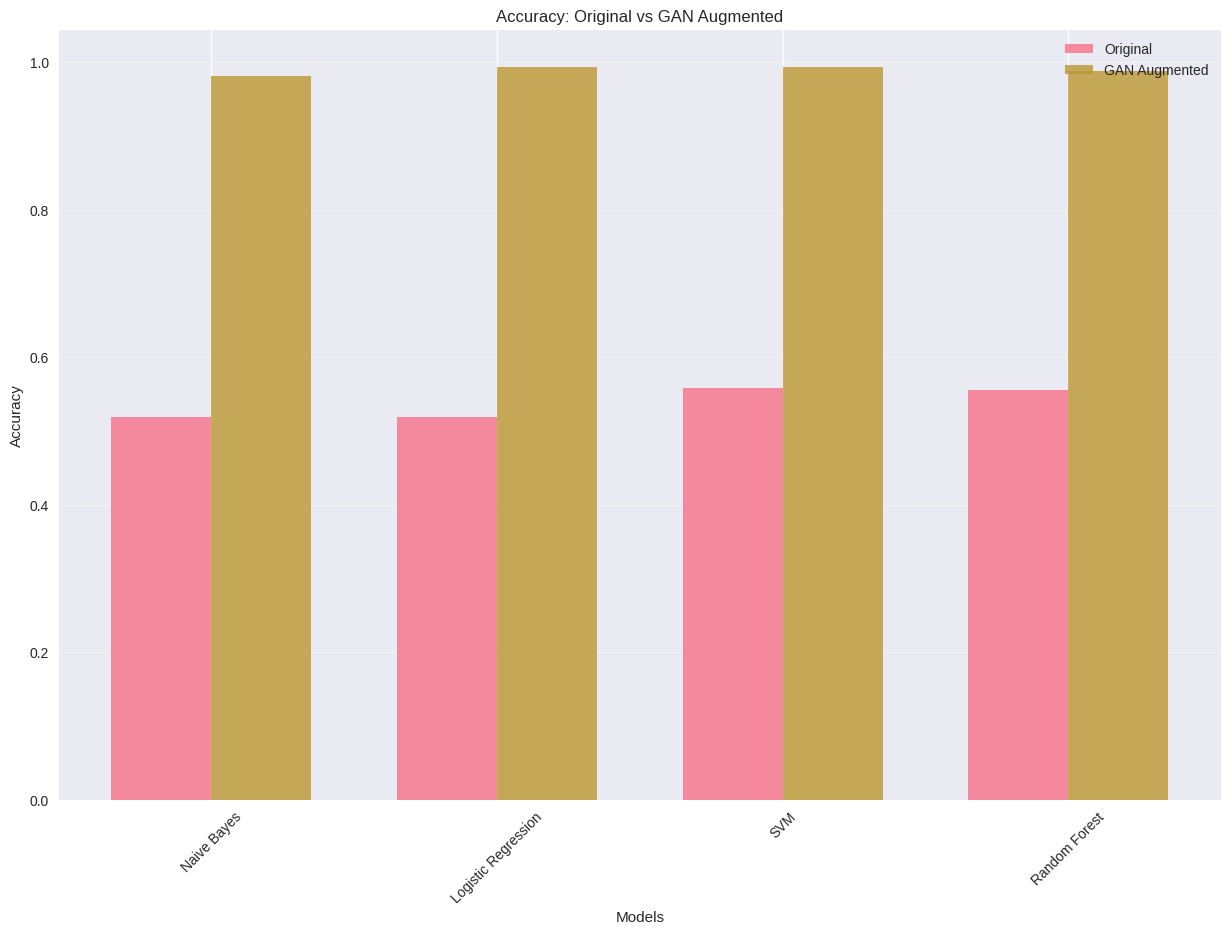

In [ ]:
plt.figure(figsize=(15, 10))
models = list(results_original_gan.keys())
original_acc = [results_original_gan[m]['accuracy'] for m in models]
gan_acc = [results_gan_augmented[m]['accuracy'] for m in models]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, original_acc, width, label='Original', alpha=0.8)
plt.bar(x + width/2, gan_acc, width, label='GAN Augmented', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy: Original vs GAN Augmented')
plt.xticks(x, models, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

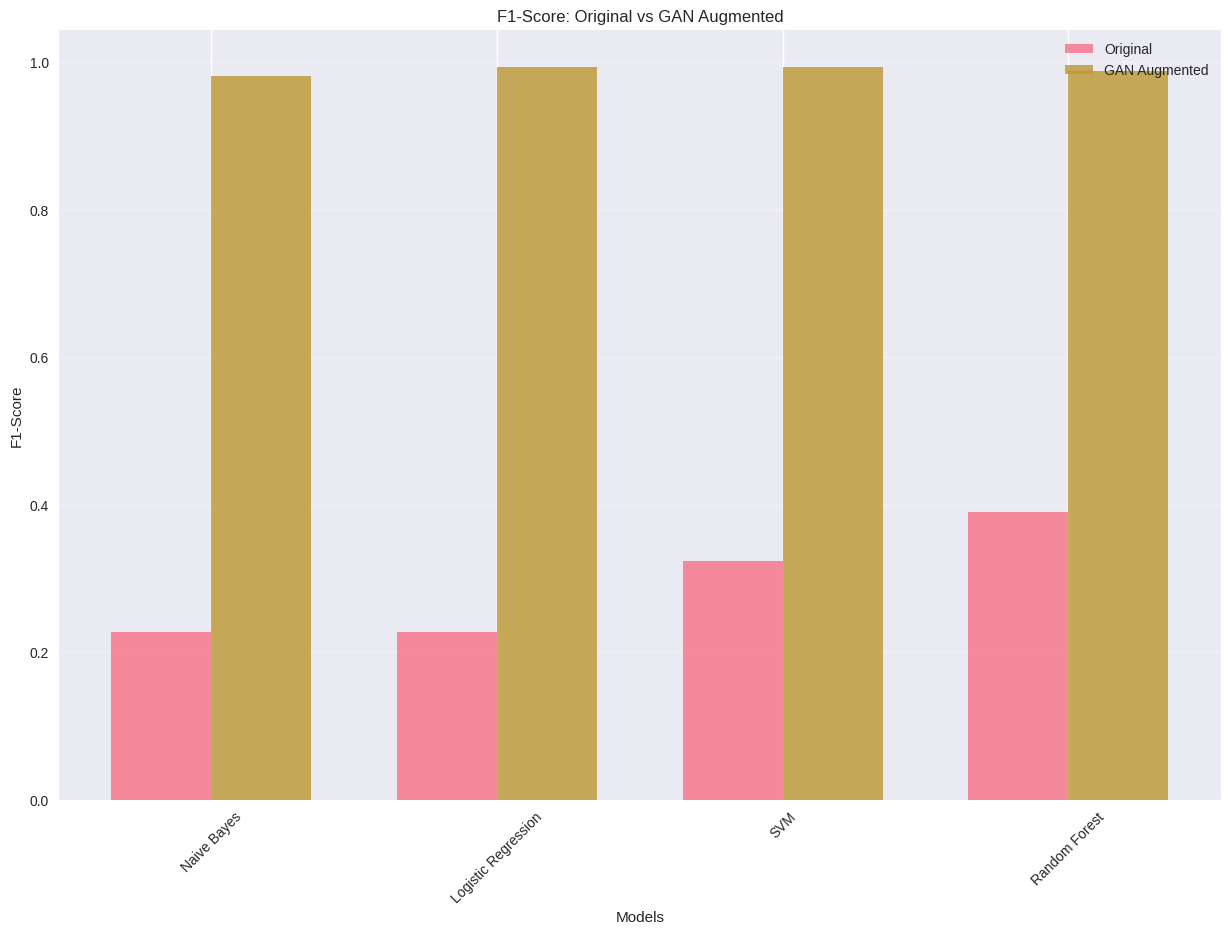

In [ ]:
plt.figure(figsize=(15, 10))
original_f1 = [results_original_gan[m]['f1'] for m in models]
gan_f1 = [results_gan_augmented[m]['f1'] for m in models]

plt.bar(x - width/2, original_f1, width, label='Original', alpha=0.8)
plt.bar(x + width/2, gan_f1, width, label='GAN Augmented', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('F1-Score')
plt.title('F1-Score: Original vs GAN Augmented')
plt.xticks(x, models, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

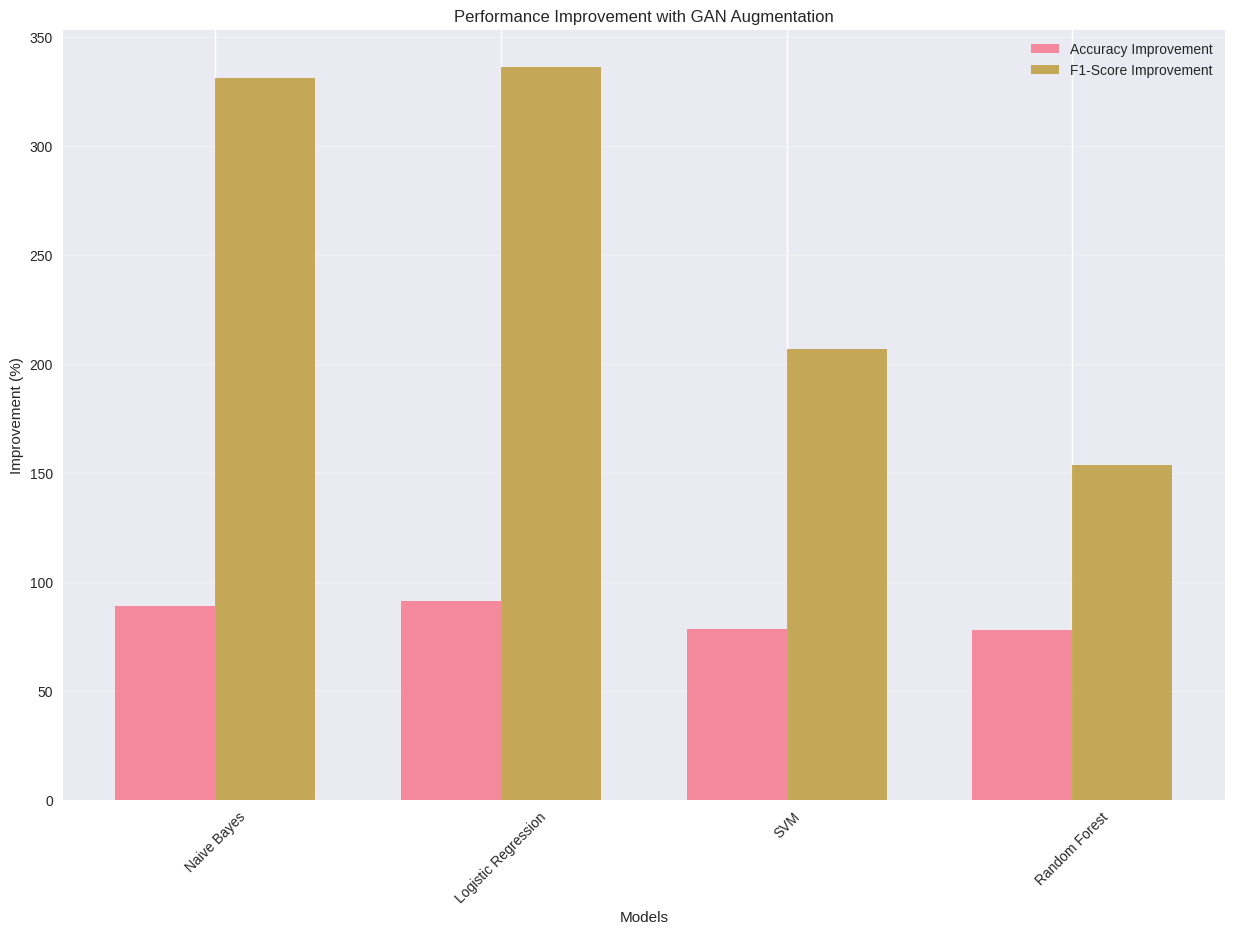

In [ ]:
plt.figure(figsize=(15, 10))
acc_improvements = [((gan_acc[i] - original_acc[i]) / original_acc[i] * 100) if original_acc[i] > 0 else 0 for i in range(len(models))]
f1_improvements = [((gan_f1[i] - original_f1[i]) / original_f1[i] * 100) if original_f1[i] > 0 else 0 for i in range(len(models))]

plt.bar(x - width/2, acc_improvements, width, label='Accuracy Improvement', alpha=0.8)
plt.bar(x + width/2, f1_improvements, width, label='F1-Score Improvement', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Improvement (%)')
plt.title('Performance Improvement with GAN Augmentation')
plt.xticks(x, models, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)


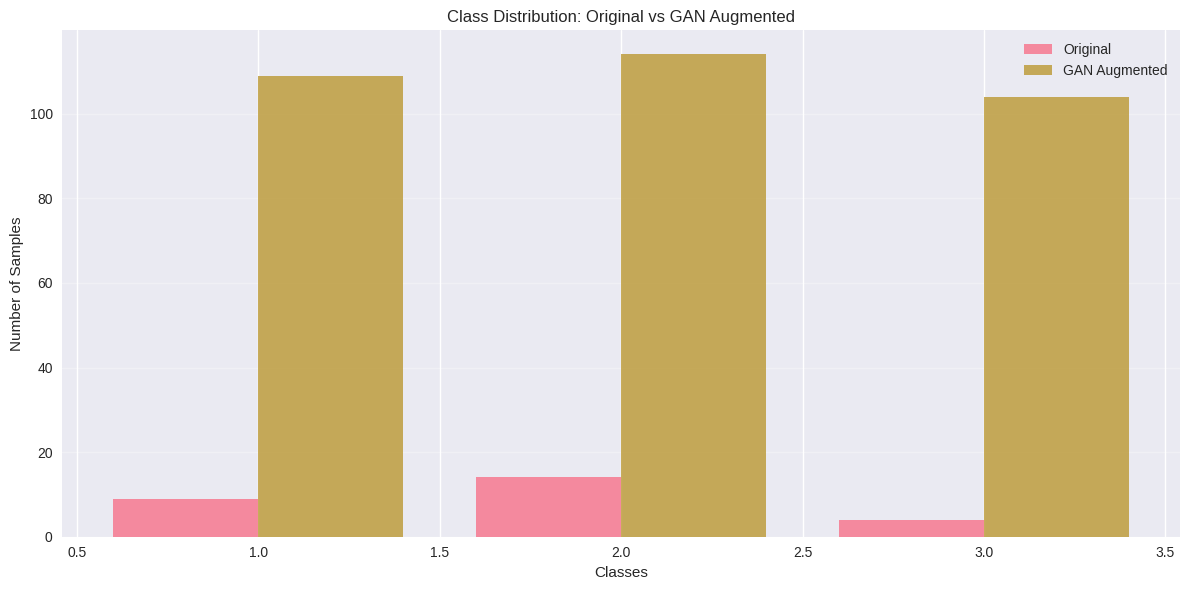

In [ ]:
plt.figure(figsize=(12, 6))
original_dist = df['Classificação'].value_counts().sort_index()
gan_dist = df_gan_augmented['Classificação'].value_counts().sort_index()

classes = original_dist.index
plt.bar(classes - 0.2, original_dist.values, 0.4, label='Original', alpha=0.8)
plt.bar(classes + 0.2, gan_dist.values, 0.4, label='GAN Augmented', alpha=0.8)

plt.xlabel('Classes')
plt.ylabel('Number of Samples')
plt.title('Class Distribution: Original vs GAN Augmented')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

In [ ]:
df_gan_augmented.to_csv(f"../CSV/data_{df['Tag'].iloc[0]}_gan_augmented.csv", index=False)

In [ ]:
heatmap_data = []
model_labels = []

# Adicionar dados originais
for model in models:
    row = []
    for metric in ['accuracy', 'f1', 'precision', 'recall']:
        row.append(results_original_gan[model][metric])
    heatmap_data.append(row)
    model_labels.append(f'{model} (Original)')

# Adicionar dados GAN-aumentados
for model in models:
    row = []
    for metric in ['accuracy', 'f1', 'precision', 'recall']:
        row.append(results_gan_augmented[model][metric])
    heatmap_data.append(row)
    model_labels.append(f'{model} (GAN)')

# Criar DataFrame para o heatmap
heatmap_df = pd.DataFrame(
    heatmap_data, 
    index=model_labels, 
    columns=['Accuracy', 'F1-Score', 'Precision', 'Recall']
)

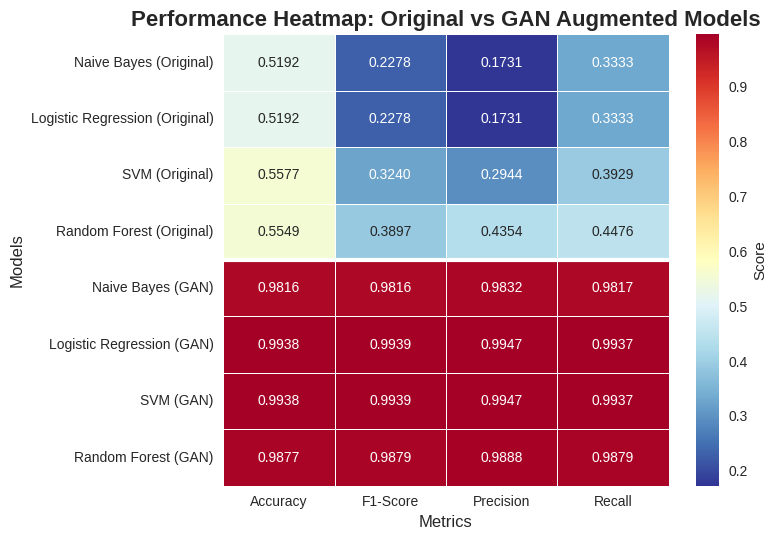

In [ ]:
sns.heatmap(
    heatmap_df, 
    annot=True, 
    fmt='.4f', 
    cmap='RdYlBu_r',
    cbar_kws={'label': 'Score'},
    linewidths=0.5,
    square=False
)

plt.title('Performance Heatmap: Original vs GAN Augmented Models', fontsize=16, fontweight='bold')
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Models', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

ax = plt.gca()
ax.axhline(y=len(models), color='white', linewidth=3)

plt.tight_layout()
plt.show()

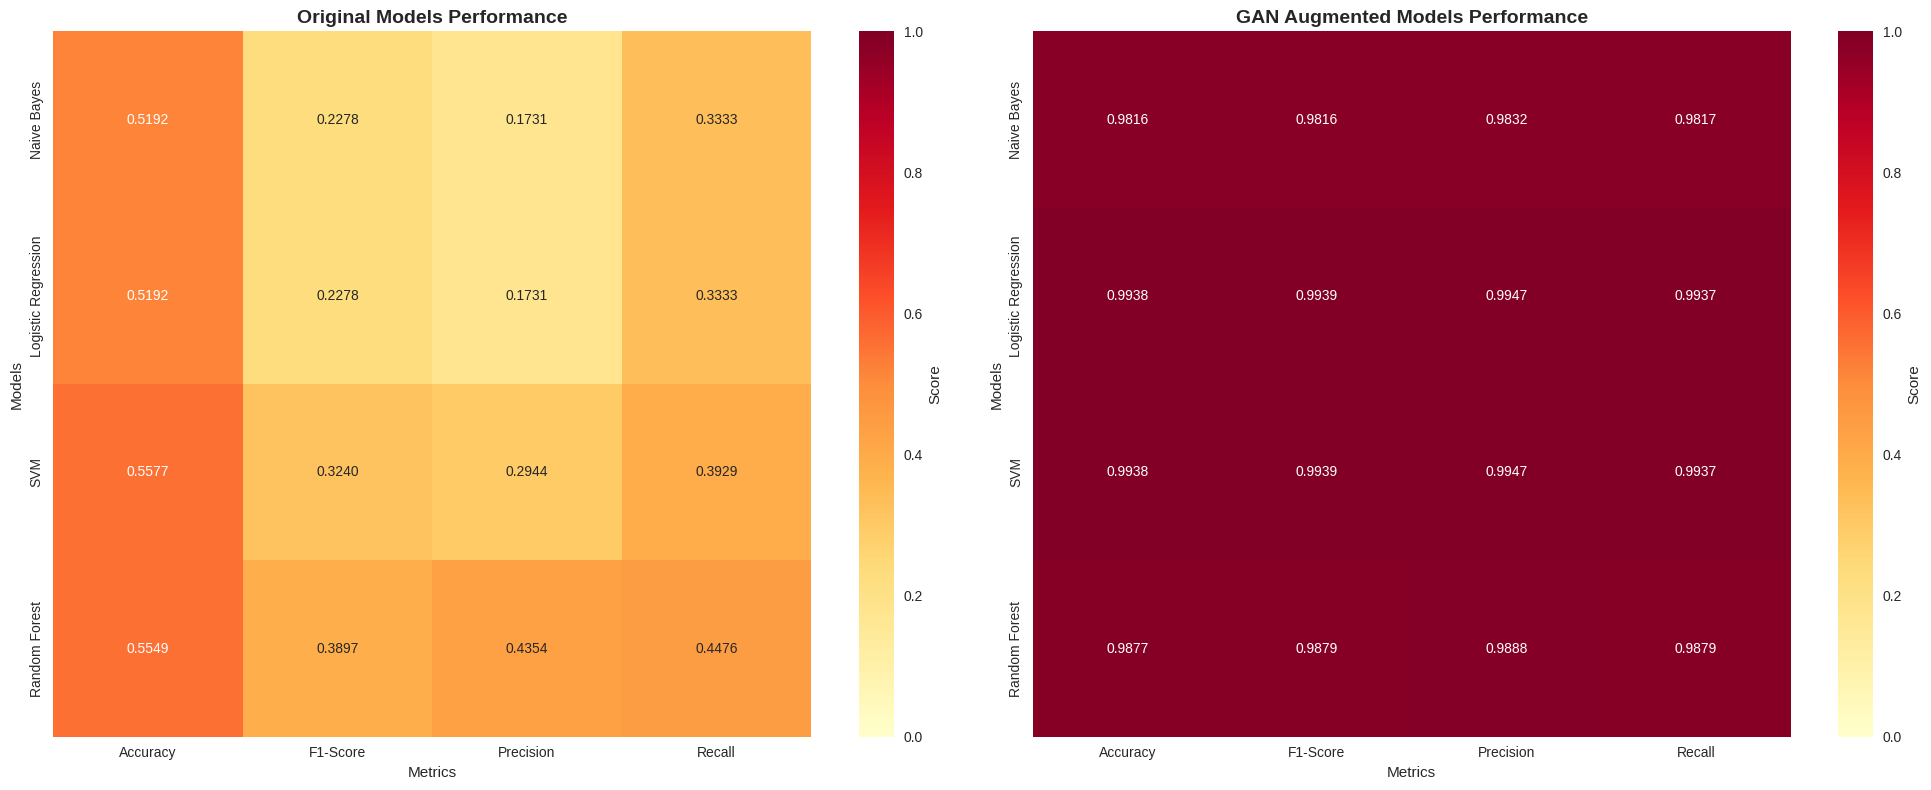

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

original_data = []
for model in models:
    row = []
    for metric in ['accuracy', 'f1', 'precision', 'recall']:
        row.append(results_original_gan[model][metric])
    original_data.append(row)

original_df = pd.DataFrame(original_data, index=models, columns=['Accuracy', 'F1-Score', 'Precision', 'Recall'])

sns.heatmap(
    original_df, 
    annot=True, 
    fmt='.4f', 
    cmap='YlOrRd',
    cbar_kws={'label': 'Score'},
    ax=ax1,
    vmin=0,
    vmax=1
)
ax1.set_title('Original Models Performance', fontsize=14, fontweight='bold')
ax1.set_xlabel('Metrics')
ax1.set_ylabel('Models')

gan_data = []
for model in models:
    row = []
    for metric in ['accuracy', 'f1', 'precision', 'recall']:
        row.append(results_gan_augmented[model][metric])
    gan_data.append(row)

gan_df = pd.DataFrame(gan_data, index=models, columns=['Accuracy', 'F1-Score', 'Precision', 'Recall'])

sns.heatmap(
    gan_df, 
    annot=True, 
    fmt='.4f', 
    cmap='YlOrRd',
    cbar_kws={'label': 'Score'},
    ax=ax2,
    vmin=0,
    vmax=1
)
ax2.set_title('GAN Augmented Models Performance', fontsize=14, fontweight='bold')
ax2.set_xlabel('Metrics')
ax2.set_ylabel('Models')

plt.tight_layout()
plt.show()

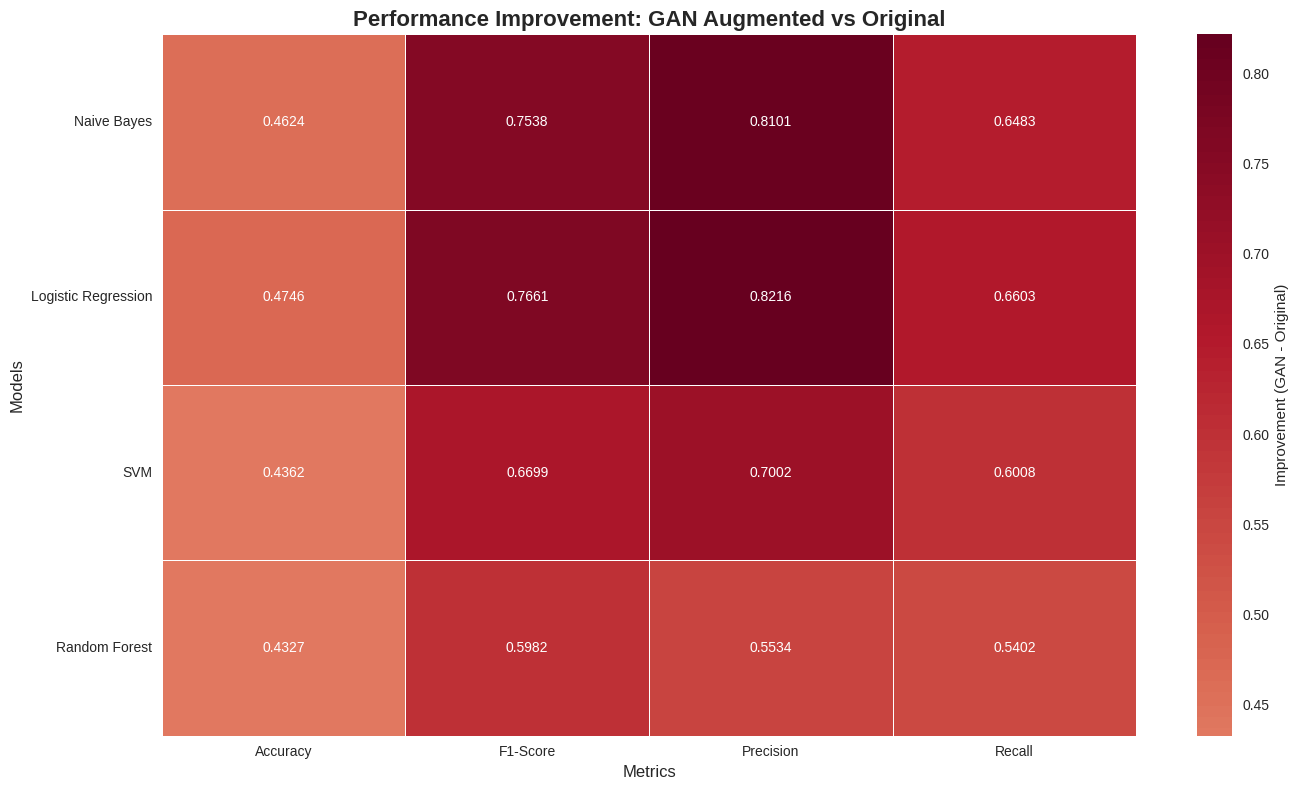

In [ ]:
plt.figure(figsize=(14, 8))

difference_data = []
for model in models:
    row = []
    for metric in ['accuracy', 'f1', 'precision', 'recall']:
        original_val = results_original_gan[model][metric]
        gan_val = results_gan_augmented[model][metric]
        difference = gan_val - original_val
        row.append(difference)
    difference_data.append(row)

difference_df = pd.DataFrame(difference_data, index=models, columns=['Accuracy', 'F1-Score', 'Precision', 'Recall'])

sns.heatmap(
    difference_df, 
    annot=True, 
    fmt='.4f', 
    cmap='RdBu_r',
    center=0,
    cbar_kws={'label': 'Improvement (GAN - Original)'},
    linewidths=0.5
)

plt.title('Performance Improvement: GAN Augmented vs Original', fontsize=16, fontweight='bold')
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Models', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()